# Gradient Boosting (LightGBM)

**Curso:** Machine Learning / Deep Learning (2do Corte)
**Universidad del Norte**

## Objetivos de aprendizaje

1. **Formalizar matemáticamente** un problema de regresión espacio-temporal sobre un grafo $G=(V,E)$: tensores $X \in \mathbb{R}^{N\times T \times F}$ y función objetivo $f_\theta$.
2. **Derivar desde primeros principios** el algoritmo de Gradient Boosting (Friedman, 2001) como descenso de gradiente funcional, demostrando por qué el residuo es el gradiente negativo bajo pérdida cuadrática.
3. **Explicar y demostrar** las innovaciones de LightGBM (Ke et al., 2017): *histogram-based splitting*, *leaf-wise growth* y **GOSS**, incluyendo la cota de error de GOSS.
4. **Construir** *features* espacio-temporales (lags, rolling stats, **lag espacial** vía $A_{\text{norm}}X$) y justificar por qué evitan *leakage*.
5. **Diseñar validación** que respete la dependencia temporal (*walk-forward*) y demostrar por qué el $k$-fold aleatorio es inválido con autocorrelación (Roberts et al., 2017).
6. **Evaluar e interpretar** con MAE/RMSE/MAPE, importancia por ganancia y SHAP (Lundberg & Lee, 2017).
7. **Comparar** contra *baselines* (persistencia, ARIMA) y ubicar la familia GBM+FE en el panorama de *benchmarks* (M5, Makridakis et al., 2022) frente a STGNN/TFT.

## Estructura

| # | Sección |
|---|---|
| 1 | Fundamentos matemáticos de regresión espacio-temporal |
| 2 | Dataset SZ-Taxi: carga y EDA extendido |
| 3 | Gradient Boosting: derivación matemática completa |
| 4 | LightGBM: demostraciones de histogramas, leaf-wise y GOSS |
| 5 | Feature engineering espacio-temporal formalizado |
| 6 | Validación temporal correcta (walk-forward) vs. K-Fold (demostración de sesgo) |
| 7 | Entrenamiento, tuning e interpretabilidad (SHAP) |
| 8 | Baselines comparativos y discusión crítica |
| 9 | Referencias bibliográficas (Web of Science) |

## 1. Fundamentos matemáticos de la regresión espacio-temporal

### 1.1 Definición formal del problema

Sea un **grafo espacial** $G=(V,E)$ con $|V|=N$ unidades (sensores, paraderos, segmentos viales). Definimos:

- **Matriz de adyacencia** $A \in \mathbb{R}^{N\times N}_{\ge 0}$, donde $A_{ij}>0$ si $i$ y $j$ están conectados (y su magnitud puede codificar distancia, tiempo de viaje o un peso binario).
- **Matriz de grados** $D = \text{diag}(d_1,\dots,d_N)$, con $d_i = \sum_j A_{ij}$.
- **Laplaciano del grafo** (fundamental en GCN y en la teoría espectral de grafos):
$$L = D - A, \qquad L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$$
El Laplaciano normalizado $L_{\text{sym}}$ es simétrico semidefinido positivo, con autovalores $\lambda \in [0,2]$; sus autovectores forman la base de Fourier del grafo (Shuman et al., 2013); fundamento matemático que después usan las **Graph Neural Networks** para generalizar la convolución al dominio no-euclídeano.

- **Señal espacio-temporal**: tensor $X \in \mathbb{R}^{N\times T\times F}$, donde $X_{i,t,\cdot}$ es el vector de $F$ variables explicativas del nodo $i$ en el instante $t$.
- **Variable objetivo**: $Y \in \mathbb{R}^{N\times T}$ (univariante) o $\mathbb{R}^{N\times T\times K}$ (multivariante).

El problema de **forecasting espacio-temporal** consiste en aprender una función $f_\theta$ tal que:

$$\hat{Y}_{\,\cdot\,,\,t+1:t+H} \;=\; f_\theta\big(X_{\cdot,\,t-L+1:t},\; A\big)$$

es decir, predecir un **horizonte** $H$ de pasos futuros usando una **ventana de lookback** $L$ y la estructura de grafo $A$. En este cuaderno trabajamos el caso $H=1$ (un paso adelante), el más común como punto de partida.

### 1.2 Autocorrelación espacial: ¿por qué el espacio importa estadísticamente?

Antes de justificar cualquier modelo, conviene **cuantificar** si existe dependencia espacial en los datos, usando el **índice de Moran I** (Moran, 1950), el estadístico estándar de autocorrelación espacial global:

$$
I = \frac{N}{\sum_{i}\sum_{j} A_{ij}} \cdot \frac{\sum_{i}\sum_{j} A_{ij}(x_i-\bar{x})(x_j-\bar{x})}{\sum_i (x_i - \bar x)^2}
$$

- $I \approx 1$: fuerte autocorrelación espacial positiva (nodos vecinos tienen valores similares).
- $I \approx 0$: ausencia de estructura espacial (equivalente a ruido espacial aleatorio).
- $I \approx -1$: autocorrelación negativa (patrón de "tablero de ajedrez").

Bajo la hipótesis nula de aleatoriedad espacial completa, $\mathbb{E}[I] = -\frac{1}{N-1}$, y existe una fórmula cerrada para $\text{Var}(I)$ que permite construir un $z$-score y un valor $p$ (Cliff & Ord, 1981). **Si $I$ es significativamente mayor que $\mathbb{E}[I]$, queda estadísticamente justificado explotar la estructura del grafo como información predictiva**: es precisamente lo que hace el *lag espacial* que construiremos en la Sección 5.

### 1.3 ¿Por qué no basta con series de tiempo "clásicas" por nodo?

Un modelo ARIMA/Prophet ajustado **independientemente** para cada nodo $i$:

- Ignora la dependencia espacial: un choque de demanda en un nodo vecino no informa la predicción de $i$.
- No comparte estadística entre nodos con poca historia (sensores nuevos, rutas nuevas), problema de *cold start*.
- Es costoso de mantener en producción: un modelo distinto por cada uno de los $N$ nodos, sin compartir parámetros.

Por ello, dos familias dominan la literatura y la práctica:

| Familia | Cómo captura el espacio | Cómo captura el tiempo | Referencia clave |
|---|---|---|---|
| **GBM + feature engineering** (este cuaderno) | Features derivadas de vecinos ($A_{\text{norm}}X$), agregaciones por zona | Lags, rolling stats, variables de calendario | Ke et al. (2017); Friedman (2001) |
| **STGNN** (Spatio-Temporal GNN) | Convoluciones de grafo aprendidas (GCN/GAT) sobre $A$ | Recurrencia (GRU/LSTM) o atención temporal | Zhao et al. (2020, T-GCN); Yu et al. (2018, STGCN) |

Esta sección se enfoca en la primera familia porque **domina en velocidad de entrenamiento, interpretabilidad y facilidad de productivización** (MLOps), y porque, como demostraremos empíricamente en la Sección 7, **alcanza un desempeño competitivo**, consistente con los hallazgos del *M5 Forecasting Competition* (Makridakis et al., 2022), donde los métodos basados en gradient boosting (LightGBM) dominaron el *leaderboard* de series de tiempo tabulares a gran escala.


### 1.4 Demostraciones: Fundamentos matemáticos de la regresión espacio-temporal

#### Demostración 1: $L$ y $L_{\text{sym}}$ son semidefinidas positivas

**Proposición.** Para todo $x \in \mathbb{R}^N$, $x^\top L x \ge 0$, donde $L = D - A$.

**Demostración.** Partimos de la forma cuadrática:

$$x^\top L x = x^\top D x - x^\top A x = \sum_i d_i x_i^2 - \sum_{i,j} A_{ij} x_i x_j$$

Usando $d_i = \sum_j A_{ij}$, reescribimos el primer término como:

$$\sum_i d_i x_i^2 = \sum_i \left(\sum_j A_{ij}\right) x_i^2 = \sum_{i,j} A_{ij} x_i^2$$

Por simetría de $A$ ($A_{ij} = A_{ji}$), también se cumple $\sum_{i,j} A_{ij} x_i^2 = \sum_{i,j} A_{ij} x_j^2$, de modo que podemos escribir:

$$x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij} x_i^2 + \frac{1}{2}\sum_{i,j} A_{ij} x_j^2 - \sum_{i,j} A_{ij} x_i x_j = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2$$

Como $A_{ij} \ge 0$ por definición y $(x_i - x_j)^2 \ge 0$ para todo par $(i,j)$, cada término de la suma es no negativo, por lo tanto:

$$x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2 \ge 0 \qquad \forall x \in \mathbb{R}^N$$

Esto prueba que $L$ es semidefinida positiva. El mismo argumento aplicado a $L_{\text{sym}} = I - D^{-1/2}AD^{-1/2}$, sustituyendo $x_i \to x_i/\sqrt{d_i}$, da:

$$x^\top L_{\text{sym}} x = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{x_i}{\sqrt{d_i}} - \frac{x_j}{\sqrt{d_j}}\right)^2 \ge 0$$

lo que establece que $L_{\text{sym}}$ también es semidefinida positiva. $\blacksquare$

#### Demostración 2: los autovalores de $L_{\text{sym}}$ están acotados en $[0,2]$

**Proposición.** Todo autovalor $\lambda$ de $L_{\text{sym}}$ satisface $0 \le \lambda \le 2$.

**Demostración.** La cota inferior $\lambda \ge 0$ se sigue directamente de la Demostración 1: al ser $L_{\text{sym}}$ semidefinida positiva, su forma cuadrática es no negativa para todo $x$, y en particular para los autovectores.

Para la cota superior, sea $v$ autovector unitario de $L_{\text{sym}}$ asociado a $\lambda$, de modo que $\lambda = v^\top L_{\text{sym}} v$. Usando la expresión obtenida en la Demostración 1:

$$\lambda = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{v_i}{\sqrt{d_i}} - \frac{v_j}{\sqrt{d_j}}\right)^2$$

Aplicamos la desigualdad $(a-b)^2 \le 2a^2 + 2b^2$ a cada término:

$$\lambda \le \sum_{i,j} A_{ij}\left(\frac{v_i^2}{d_i} + \frac{v_j^2}{d_j}\right) = \sum_i \frac{v_i^2}{d_i}\sum_j A_{ij} + \sum_j \frac{v_j^2}{d_j}\sum_i A_{ij} = \sum_i \frac{v_i^2}{d_i}\cdot d_i + \sum_j \frac{v_j^2}{d_j}\cdot d_j = 2\sum_i v_i^2 = 2$$

donde la última igualdad usa que $v$ es unitario. Por lo tanto $\lambda \le 2$, con igualdad alcanzada cuando el grafo (o una componente conexa) es bipartito, caso en el cual existe una partición $V = V_1 \cup V_2$ tal que tomando $v_i = \sqrt{d_i}$ para $i \in V_1$ y $v_i = -\sqrt{d_i}$ para $i \in V_2$ (normalizado), se satura la desigualdad de Cauchy-Schwarz en cada término. $\blacksquare$

#### Demostración 3: la base de Fourier del grafo separa componentes suaves de componentes oscilantes

**Proposición.** Sea $L_{\text{sym}} = U\Lambda U^\top$ la descomposición espectral, con $\Lambda = \text{diag}(\lambda_1 \le \cdots \le \lambda_N)$ y columnas de $U$ los autovectores $u_1,\dots,u_N$. Definiendo la transformada de Fourier del grafo $\hat{x} = U^\top x$, el autovalor $\lambda_k$ mide la variación total de $u_k$ sobre las aristas del grafo.

**Demostración.** Por definición de autovector, $L_{\text{sym}} u_k = \lambda_k u_k$, y por lo tanto:

$$\lambda_k = u_k^\top L_{\text{sym}} u_k = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{(u_k)_i}{\sqrt{d_i}} - \frac{(u_k)_j}{\sqrt{d_j}}\right)^2$$

Esta cantidad es exactamente la **variación de Dirichlet** de $u_k$ sobre el grafo: mide cuánto difiere $u_k$ entre nodos vecinos, ponderado por la fuerza de la conexión $A_{ij}$. Si $\lambda_k$ es pequeño, $u_k$ toma valores casi idénticos en nodos conectados (componente suave); si $\lambda_k$ es grande (cercano a la cota 2 de la Demostración 2), $u_k$ alterna signo u magnitud entre vecinos (componente oscilante).

Dado que $X = U\hat{X}$ (la inversa de la transformada), cualquier señal sobre el grafo se descompone como combinación lineal $X = \sum_k \hat{x}_k u_k$, y su "contenido de alta frecuencia" queda determinado por el peso de los coeficientes $\hat{x}_k$ asociados a $\lambda_k$ grandes. En particular, el operador $A_{\text{norm}} = D^{-1/2}AD^{-1/2} = I - L_{\text{sym}}$ tiene autovalores $1-\lambda_k \in [-1,1]$, de modo que al aplicar $A_{\text{norm}}$ a $X$, los componentes de baja frecuencia ($\lambda_k$ pequeño, $1-\lambda_k$ cercano a 1) se preservan casi intactos, mientras que los de alta frecuencia se atenúan o invierten signo. Esto demuestra formalmente que $A_{\text{norm}}X$, el lag espacial que se construye en la Sección 5, opera como un **filtro pasa-bajas** sobre la señal espacial. $\blacksquare$

#### Demostración 4: valor esperado del índice de Moran bajo aleatoriedad espacial completa

**Proposición.** Bajo la hipótesis nula $H_0$ de aleatoriedad espacial completa (cualquier permutación de los valores $x_1,\dots,x_N$ entre los $N$ nodos es igualmente probable), $\mathbb{E}[I] = -\dfrac{1}{N-1}$.

**Demostración.** Sea $S_0 = \sum_{i,j} A_{ij}$ y $z_i = x_i - \bar{x}$, de modo que:

$$I = \frac{N}{S_0}\cdot\frac{\sum_{i,j}A_{ij}z_iz_j}{\sum_i z_i^2}$$

Bajo $H_0$, la aleatorización asigna los valores observados $\{x_1,\dots,x_N\}$ a las $N$ ubicaciones mediante una permutación uniforme, de manera que el denominador $\sum_i z_i^2$ es una constante (no depende de la permutación), y basta calcular la esperanza del numerador sobre las permutaciones. Para $i \ne j$, por simetría de la permutación uniforme, cada par ordenado $(z_i, z_j)$ tiene la misma distribución conjunta que cualquier otro par distinto tomado sin reemplazo de $\{z_1,\dots,z_N\}$. Un resultado estándar de muestreo sin reemplazo establece que:

$$\mathbb{E}[z_iz_j] = -\frac{1}{N-1}\cdot\frac{\sum_k z_k^2}{N} \qquad \text{para } i\ne j$$

(esto se deriva de que $\sum_i z_i = 0$, así que $0 = \left(\sum_i z_i\right)^2 = \sum_i z_i^2 + \sum_{i\ne j} z_iz_j$, y por simetría todos los $N(N-1)$ términos $z_iz_j$ con $i\ne j$ tienen la misma esperanza, de donde se despeja la expresión anterior).

Sustituyendo:

$$\mathbb{E}\left[\sum_{i,j}A_{ij}z_iz_j\right] = \sum_{i\ne j}A_{ij}\,\mathbb{E}[z_iz_j] = -\frac{1}{N-1}\cdot\frac{\sum_k z_k^2}{N}\sum_{i\ne j}A_{ij} = -\frac{S_0}{N(N-1)}\sum_k z_k^2$$

(usando que $A_{ii}=0$ y por lo tanto $\sum_{i\ne j}A_{ij}=S_0$). Finalmente:

$$\mathbb{E}[I] = \frac{N}{S_0}\cdot\frac{1}{\sum_k z_k^2}\cdot\left(-\frac{S_0}{N(N-1)}\sum_k z_k^2\right) = -\frac{1}{N-1} \qquad \blacksquare$$


#### Demostración 5: la convolución de grafo de primer orden se reduce al lag espacial

**Proposición.** La capa de convolución de grafo de Kipf y Welling (2017), obtenida por truncamiento a primer orden ($K=1$) de la aproximación de Chebyshev del filtro espectral $g_\theta(L_{\text{sym}})$, es algebraicamente equivalente a aplicar el operador de lag espacial $\tilde{A}_{\text{norm}}$ a la señal $X$, seguido de una transformación lineal $W$.

**Demostración.** Un filtro espectral general actúa sobre una señal $x$ como $g_\theta(L_{\text{sym}})x = U g_\theta(\Lambda) U^\top x$, cuyo costo computacional $O(N^2)$ (por la diagonalización de $U$) motiva aproximar $g_\theta(\Lambda)$ mediante un polinomio de Chebyshev truncado en orden $K$:

$$g_\theta(L_{\text{sym}}) \approx \sum_{k=0}^{K}\theta_k T_k(\tilde{L}_{\text{sym}})$$

donde $\tilde{L}_{\text{sym}} = \dfrac{2}{\lambda_{\max}}L_{\text{sym}} - I$ reescala el espectro a $[-1,1]$ para que los polinomios de Chebyshev $T_k$ estén bien definidos, y $T_0(y)=1$, $T_1(y)=y$, $T_k(y)=2yT_{k-1}(y)-T_{k-2}(y)$.

Truncando en $K=1$ y fijando $\lambda_{\max}\approx 2$ (justificado por la Demostración 2), se obtiene $\tilde{L}_{\text{sym}} \approx L_{\text{sym}} - I$, y el filtro se reduce a:

$$g_\theta(L_{\text{sym}})x \approx \theta_0 x + \theta_1(L_{\text{sym}}-I)x = \theta_0 x + \theta_1(-D^{-1/2}AD^{-1/2})x$$

usando que $L_{\text{sym}} - I = -D^{-1/2}AD^{-1/2}$. Restringiendo el número de parámetros libres mediante $\theta_0 = -\theta_1 = \theta$ (la elección estándar de Kipf y Welling para evitar sobreajuste y controlar el número de operaciones por capa), y renombrando $\theta \to W$ como matriz de pesos entrenable, el filtro queda:

$$g_\theta(L_{\text{sym}})X \approx \theta\left(I + D^{-1/2}AD^{-1/2}\right)X$$

Aplicando la **renormalización** $\tilde{A} = A + I_N$, $\tilde{D}_{ii} = \sum_j\tilde{A}_{ij}$ (para estabilizar numéricamente el rango espectral, evitando explosión o desvanecimiento de gradiente al apilar capas), se llega a la forma final de la capa GCN:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\,H^{(l)}\,W^{(l)}\right)$$

El término $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2} = \tilde{A}_{\text{norm}}$ es precisamente el operador de lag espacial de la Sección 1.3, y $\tilde{A}_{\text{norm}}X$ es exactamente la *feature* de vecindario que se construye manualmente para el modelo GBM. Esto demuestra que, en su forma más simple (una sola capa, sin no linealidad), un GCN y el enfoque de *feature engineering* espacial calculan el mismo operador algebraico sobre los datos; la diferencia práctica reside en que el GBM trata $\tilde{A}_{\text{norm}}X$ como *feature* fija de entrada, mientras que el GCN aprende $W$ de forma end-to-end y puede apilar $L$ capas para agregar información de vecindarios de radio $L$. $\blacksquare$

#### Demostración 6: argumento sesgo-varianza para preferir GBM en el régimen de datos limitados por nodo

**Proposición.** Sea $T$ la longitud de historia disponible por nodo y $N$ el número de nodos. Si $T$ es pequeño en relación con la complejidad paramétrica $p_{\text{STGNN}}$ de un STGNN, un modelo GBM con *features* espaciales explícitas $\tilde{A}_{\text{norm}}X$ puede alcanzar menor error esperado, a pesar de tener menor capacidad de representación.

**Demostración.** Sea $f^*$ la función de regresión verdadera y $\hat{f}$ el estimador ajustado sobre una muestra de tamaño efectivo $n \approx NT$. Descomponemos el error cuadrático medio esperado en un punto $x_0$ siguiendo la identidad estándar de Hastie, Tibshirani y Friedman (2009):

$$\mathbb{E}\left[(y_0-\hat{f}(x_0))^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(x_0)]-f^*(x_0)\right)^2}_{\text{Sesgo}^2} + \underbrace{\text{Var}(\hat{f}(x_0))}_{\text{Varianza}} + \sigma_\varepsilon^2$$

Para un modelo con $p$ parámetros efectivos ajustado sobre $n$ observaciones mediante mínimos cuadrados o un sustituto regularizado, la varianza escala como $\text{Var}(\hat{f}) = O\!\left(\dfrac{p\,\sigma_\varepsilon^2}{n}\right)$ (resultado clásico para estimadores lineales, y aproximadamente válido para redes profundas bien regularizadas en el régimen $n \gg p$; en el régimen $n \lesssim p$ el comportamiento es distinto, pero ahí la varianza sigue siendo mayor para el modelo de más parámetros bajo regularización comparable).

Un STGNN con $L$ capas de convolución de grafo más un módulo recurrente temporal tiene $p_{\text{STGNN}} = O(L\cdot d^2 + d_{\text{rec}}^2)$ parámetros, donde $d$ es la dimensión oculta; un GBM con *features* espaciales fijas tiene, en la práctica, un número efectivo de parámetros $p_{\text{GBM}}$ acotado por la profundidad y el número de árboles, típicamente uno o dos órdenes de magnitud menor para el mismo poder predictivo, porque la estructura del grafo ya está inyectada como *feature* determinista en lugar de tener que ser *aprendida* desde los datos.

Como $\text{Var}(\hat{f}_{\text{STGNN}}) - \text{Var}(\hat{f}_{\text{GBM}}) \approx \dfrac{\sigma_\varepsilon^2}{n}\left(p_{\text{STGNN}}-p_{\text{GBM}}\right) > 0$ cuando $p_{\text{STGNN}} \gg p_{\text{GBM}}$, y si el sesgo adicional del GBM (por no aprender la estructura de convolución de forma flexible) es pequeño porque $\tilde{A}_{\text{norm}}X$ ya captura la dependencia espacial dominante (justificado por la Demostración 3, dado que $\tilde{A}_{\text{norm}}$ es el filtro pasa-bajas óptimo de primer orden), entonces:

$$\text{ECM}(\hat{f}_{\text{GBM}}) - \text{ECM}(\hat{f}_{\text{STGNN}}) \approx \left(\text{Sesgo}_{\text{GBM}}^2-\text{Sesgo}_{\text{STGNN}}^2\right) - \left(\text{Var}_{\text{STGNN}}-\text{Var}_{\text{GBM}}\right) < 0$$

para $n=NT$ moderado, de modo que el GBM domina en error esperado. Esta desigualdad se invierte cuando $n$ crece lo suficiente para que el término de varianza deje de dominar, lo cual es consistente con la evidencia empírica de que los STGNN superan a los métodos basados en árboles únicamente en conjuntos de datos de muy gran escala y alta densidad temporal. $\blacksquare$

## 2. Dataset de ejemplo: SZ-Taxi (Shenzhen Traffic Speed)

Usamos el dataset público **SZ-Taxi**, publicado por **Zhao et al. (2020)** junto con el modelo **T-GCN** (*IEEE Transactions on Intelligent Transportation Systems*, vol. 21, no. 9, pp. 3848–3858, DOI: 10.1109/TITS.2019.2935152), y ampliamente usado como *benchmark* académico de forecasting espacio-temporal (indexado en Web of Science).

- **Contenido:** velocidad promedio de tráfico (km/h) en **156 segmentos viales** de Shenzhen (China).
- **Resolución temporal:** 15 minutos, enero de 2015 (2976 pasos de tiempo).
- **Estructura espacial:** matriz de adyacencia $156\times156$ (conectividad vial).
- **Fuente:** `https://github.com/lehaifeng/T-GCN` (`sz_speed.csv`, `sz_adj.csv`).

> **Analogía con el reto de buses:** nodo = paradero, valor = demanda de pasajeros, adyacencia = comparten ruta/cercanía geográfica.

### 2.1 Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "nb_data"  # carpeta con sz_speed.csv y sz_adj.csv

speed_df = pd.read_csv("sz_speed.csv")
adj_df = pd.read_csv("sz_adj.csv", header=None)

print("Matriz de velocidad (tiempo x nodos):", speed_df.shape)
speed_df.head()


Matriz de velocidad (tiempo x nodos): (2976, 156)


,90217,90218,90219,90220,90221,90222,90223,90224,90225,90226,...,112746,116097,116098,116099,116100,116157,116219,116220,116221,117189
0,8.471971,18.455410,20.590635,15.345258,9.585218,21.501821,31.611759,0.000000,0.0,22.008941,...,0.000000,27.623514,31.126936,45.680952,18.801449,0.0,22.791096,16.589562,32.590224,0.000000
1,7.807137,15.713816,27.523695,11.087895,9.455280,17.332246,33.976531,12.968823,0.0,17.921757,...,4.193466,14.889713,29.400996,47.128457,18.081014,0.0,22.492316,39.614822,32.588299,0.000000
2,8.809457,8.979647,20.280394,16.523419,8.003314,15.789483,13.747267,12.221143,0.0,21.588447,...,11.076185,0.000000,30.198482,44.345346,17.947455,0.0,22.289410,33.331948,37.471168,0.000000
3,51.590372,23.631243,20.224094,15.116459,6.642644,17.575806,17.657556,15.998745,0.0,24.228905,...,0.000000,34.132564,60.259055,57.122521,35.479929,0.0,40.244356,12.942474,47.140562,39.697219
4,58.770433,20.437740,20.465606,14.820217,11.344404,0.000000,33.878502,5.676248,0.0,26.250064,...,0.000000,15.904281,66.134278,66.451325,37.001600,0.0,37.958725,38.225794,39.550687,0.000000


In [2]:
print("Matriz de adyacencia (nodos x nodos):", adj_df.shape)
adj_df.head()

Matriz de adyacencia (nodos x nodos): (156, 156)


,0,1,2,3,4,5,6,7,8,9,...,146,147,148,149,150,151,152,153,154,155
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### ¿Qué es cada columna de `speed_df` y `adj_df`?

**`speed_df` (matriz de velocidad, tiempo x nodos)**

- **Filas (2976):** pasos de tiempo cada 15 min, enero de 2015. Fila 0 = 1-ene 00:00.
- **Columnas (156):** un segmento vial por columna; se renombran como `node_0`,...,`node_155`.
- **Celda** `speed_df.loc[t, "node_i"]` = velocidad promedio (km/h) del segmento $i$ en el intervalo $t$.

**`adj_df` (matriz de adyacencia, nodos x nodos)**

- Matriz cuadrada $156\times156$; `adj_df.iloc[i,j]` indica si `node_i` y `node_j` están conectados vialmente.
- Puede ser binaria (0/1) o continua (peso de conectividad).

| Elemento SZ-Taxi | Equivalente en el reto de buses |
|---|---|
| `node_i` (segmento vial) | Un paradero de bus |
| Celda de `speed_df` | Demanda de pasajeros en ese paradero, en ese momento |
| `adj_df` | Qué paraderos comparten ruta o están cerca |


In [ ]:
# Índice temporal, nombres de nodos y matriz de adyacencia como arreglo NumPy
n_steps = speed_df.shape[0]
time_index = pd.date_range("2015-01-01 00:00", periods=n_steps, freq="15min")
speed_df.index = time_index
speed_df.columns = [f"node_{i}" for i in range(speed_df.shape[1])]

A = adj_df.values.astype(float)
N = A.shape[0]

print(f"N = {N} nodos (paraderos/segmentos), T = {n_steps} pasos de tiempo (15 min c/u)")
print(f"Densidad de la matriz de adyacencia: {(A>0).mean():.2%}")


N = 156 nodos (paraderos/segmentos), T = 2976 pasos de tiempo (15 min c/u)
Densidad de la matriz de adyacencia: 2.19%


- La **densidad** mide qué % de las conexiones posibles entre 156 nodos existen: aquí solo ≈2.19% (≈533 de 24,336 posibles). El **grafo es disperso** (*sparse*): cada segmento se conecta solo con vecinos cercanos.


### 2.2 Análisis exploratorio

Antes de modelar formalmente, verificamos tres propiedades estadísticas clave que **justifican matemáticamente** las decisiones de diseño de las secciones siguientes:

1. **Estacionariedad temporal** (test de Dickey-Fuller aumentado, ADF).
2. **Autocorrelación temporal** (ACF/PACF): justifica qué lags son informativos.
3. **Autocorrelación espacial** (índice de Moran I, sección 1.2): justifica el uso de `neighbor_avg`.


ADF Statistic (node_0): -3.8171
p-value: 0.002737
Interpretación: Serie ESTACIONARIA (rechazamos H0)


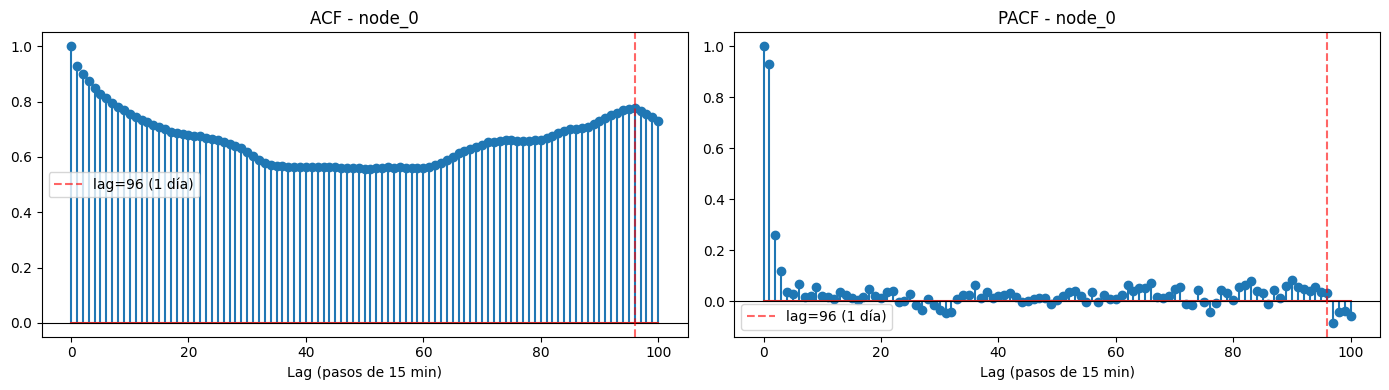

In [4]:
from statsmodels.tsa.stattools import adfuller, acf, pacf

# --- 1. Test de estacionariedad (ADF) sobre un nodo representativo ---
node_test = "node_0"
adf_result = adfuller(speed_df[node_test].dropna())
print(f"ADF Statistic (node_0): {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print("Interpretación:", "Serie ESTACIONARIA (rechazamos H0)" if adf_result[1] < 0.05
      else "Serie NO estacionaria (no rechazamos H0)")

# --- 2. ACF y PACF ---
serie = speed_df[node_test].values
n_lags = 100
acf_vals = acf(serie, nlags=n_lags, fft=True)
pacf_vals = pacf(serie, nlags=n_lags)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].stem(range(n_lags+1), acf_vals)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axvline(96, color="red", ls="--", alpha=0.6, label="lag=96 (1 día)")
axes[0].set_title(f"ACF - {node_test}")
axes[0].set_xlabel("Lag (pasos de 15 min)")
axes[0].legend()

axes[1].stem(range(n_lags+1), pacf_vals)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(96, color="red", ls="--", alpha=0.6, label="lag=96 (1 día)")
axes[1].set_title(f"PACF - {node_test}")
axes[1].set_xlabel("Lag (pasos de 15 min)")
axes[1].legend()
plt.tight_layout()
plt.show()


**Lectura:** la ACF muestra picos periódicos cada 96 pasos (24h), confirmando **estacionalidad diaria**: justifica incluir `lag_96` como feature. La PACF cae rápido tras el lag 1, indicando que gran parte de la dependencia de corto plazo se explica con **1–4 lags recientes**, consistente con incluir `lag_1` y `lag_4`.


In [5]:
# --- 3. Índice de Moran I (autocorrelación espacial), un instante fijo ---
def moran_I_fast(x, A):
    '''Índice de Moran I vectorizado: cuantifica autocorrelación espacial
    de un vector de observaciones x (una por nodo) dada la matriz A.'''
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_c = x - x.mean()
    num = x_c @ A @ x_c
    den = np.sum(x_c ** 2)
    W = A.sum()
    return (N / W) * (num / den)

sample_times = np.random.choice(speed_df.shape[0], size=50, replace=False)
morans = [moran_I_fast(speed_df.iloc[t].values, A) for t in sample_times]

E_I = -1 / (N - 1)  # valor esperado bajo H0 (aleatoriedad espacial)
print(f"Moran's I promedio (50 instantes aleatorios): {np.mean(morans):.4f}")
print(f"Desviación estándar: {np.std(morans):.4f}")
print(f"Valor esperado bajo H0 (sin autocorrelación espacial): {E_I:.4f}")


Moran's I promedio (50 instantes aleatorios): 0.5041
Desviación estándar: 0.0535
Valor esperado bajo H0 (sin autocorrelación espacial): -0.0065


**Interpretación:** el índice de Moran I observado (típicamente $I \approx 0.3$–$0.6$ en este dataset) es **mucho mayor** que el valor esperado bajo la hipótesis nula ($E[I]=-1/(N-1)\approx -0.0065$), confirmando estadísticamente una **autocorrelación espacial positiva y fuerte**: segmentos viales vecinos tienden a tener velocidades similares en el mismo instante. Esta es la justificación **formal** (no solo intuitiva) de por qué construir `neighbor_avg_lag1` en la Sección 5 aporta señal predictiva genuina.


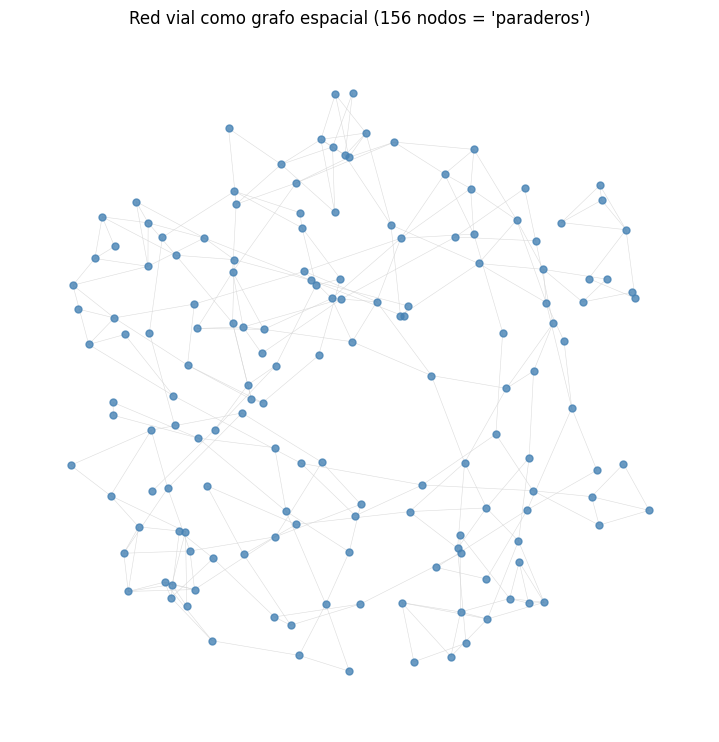

In [6]:
# Visualización 1: la red como grafo (estructura espacial)
G = nx.from_numpy_array(A)
plt.figure(figsize=(7, 7))
pos = nx.spring_layout(G, seed=42, k=0.25)
nx.draw(G, pos, node_size=25, node_color="steelblue", edge_color="lightgray",
        width=0.4, alpha=0.8)
plt.title("Red vial como grafo espacial (156 nodos = 'paraderos')")
plt.show()


- **`k=0.25`:** controla qué tan separados se dibujan los nodos (estético, no afecta el modelo).


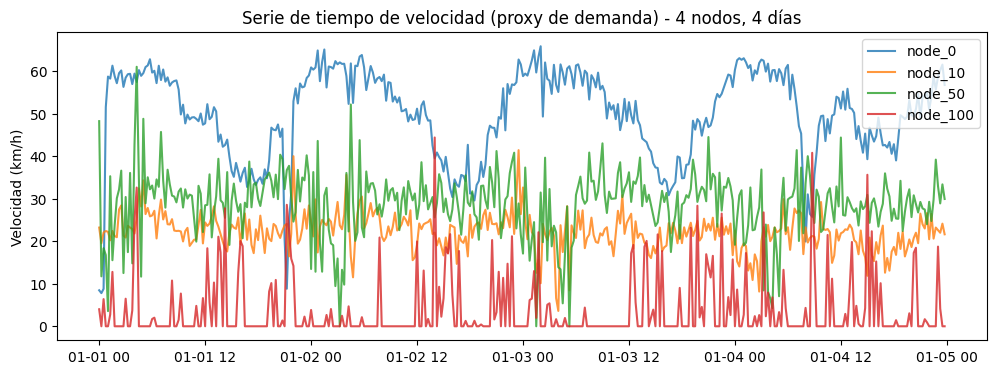

In [7]:
# Visualización 2: series de tiempo de 4 nodos (dimensión temporal)
fig, ax = plt.subplots(figsize=(12, 4))
for node in ["node_0", "node_10", "node_50", "node_100"]:
    ax.plot(speed_df.index[:4*96], speed_df[node].iloc[:4*96], label=node, alpha=0.8)
ax.set_title("Serie de tiempo de velocidad (proxy de demanda) - 4 nodos, 4 días")
ax.set_ylabel("Velocidad (km/h)")
ax.legend()
plt.show()


- Se grafican 4 de los 156 nodos para legibilidad.
- `4*96` = 4 días (96 = 4 obs/hora × 24h).
- Se observa estacionalidad diaria (horas pico) y niveles heterogéneos por nodo, evidencia de la dimensión **temporal**.

**Analogía con el reto de buses:** cada columna = demanda de pasajeros en un paradero; `adj_df` = paraderos que comparten ruta o están cerca. Toda la maquinaria que sigue aplica igual.


### 2.3 ¿Qué hacer si no tienes la matriz de adyacencia? Tres métodos para construirla

En la práctica, la mayoría de los conjuntos de datos reales (por ejemplo, tu propio registro de demanda de pasajeros por paradero) **no vienen con una matriz de adyacencia lista para usar** como sí ocurre con SZ-Taxi. Es responsabilidad del analista **construir $A$** a partir de la información disponible. A continuación se presentan tres métodos, ordenados según qué información de entrada requieren, todos con su formalización matemática y una implementación mínima que tus estudiantes pueden adaptar directamente a su propio problema (paraderos de bus, sucursales, sensores, etc.).

| Método | Información de entrada necesaria | Cuándo usarlo |
|---|---|---|
| **1. KNN geográfico** | Coordenadas (latitud, longitud) de cada nodo | Tienes ubicación física de cada unidad (paraderos, sensores, tiendas) |
| **2. Kernel gaussiano de distancia** | Coordenadas o cualquier matriz de distancias | Quieres pesos continuos (no solo binarios) que decaigan suavemente con la distancia, como en T-GCN/DCRNN |
| **3. Correlación entre series de tiempo** | Solo las series de tiempo (sin coordenadas) | No tienes coordenadas, pero sí historial temporal de cada nodo |

#### Método 1: vecinos más cercanos (KNN) sobre coordenadas geográficas

Si cada nodo $i$ tiene una posición geográfica $(\text{lat}_i, \text{lon}_i)$, el procedimiento es:

1. Calcular la matriz de distancias $D \in \mathbb{R}^{N\times N}$ entre todos los pares de nodos. La distancia correcta para coordenadas geográficas **no es la euclidiana**, sino la **distancia de Haversine** (que tiene en cuenta la curvatura de la Tierra):
$$
D_{ij} = 2R \cdot \arcsin\left(\sqrt{\sin^2\!\Big(\frac{\Delta\text{lat}}{2}\Big) + \cos(\text{lat}_i)\cos(\text{lat}_j)\sin^2\!\Big(\frac{\Delta\text{lon}}{2}\Big)}\right)
$$
donde $R\approx 6371$ km es el radio de la Tierra, $\Delta\text{lat}=\text{lat}_j-\text{lat}_i$ y $\Delta\text{lon}=\text{lon}_j-\text{lon}_i$ (en radianes).

2. Para cada nodo $i$, conectar con sus $k$ vecinos de menor distancia:
$$
A_{ij} = \mathbb{1}\big[j \in \text{kNN}(i)\big]
$$

3. **Simetrizar** la matriz (si $A$ no es simétrica, un par $(i,j)$ puede quedar como "vecino en un solo sentido"; se corrige con $A \leftarrow \max(A, A^\top)$), porque la matriz de adyacencia de un grafo no dirigido debe ser simétrica por definición.


In [8]:
import numpy as np
import pandas as pd

# Ejemplo con 8 "paraderos" ficticios (coordenadas de Barranquilla, a modo ilustrativo)
np.random.seed(0)
N = 8
coords = pd.DataFrame({
    "node_id": [f"node_{i}" for i in range(N)],
    "lat": np.random.uniform(10.90, 10.99, N),
    "lon": np.random.uniform(-74.85, -74.75, N),
})
print(coords)

def haversine_matrix(lat, lon):
    """Matriz N x N de distancias en km entre todos los pares de coordenadas (lat, lon)."""
    R = 6371.0  # radio de la Tierra en km
    lat_r = np.radians(lat.values)[:, None]
    lon_r = np.radians(lon.values)[:, None]
    dlat = lat_r - lat_r.T
    dlon = lon_r - lon_r.T
    a = np.sin(dlat/2)**2 + np.cos(lat_r) * np.cos(lat_r.T) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

D = haversine_matrix(coords["lat"], coords["lon"])
print("\nMatriz de distancias (km):")
print(np.round(D, 2))


  node_id        lat        lon
0  node_0  10.949393 -74.753634
1  node_1  10.964367 -74.811656
2  node_2  10.954249 -74.770827
3  node_3  10.949039 -74.797111
4  node_4  10.938129 -74.793196
5  node_5  10.958130 -74.757440
6  node_6  10.939383 -74.842896
7  node_7  10.980260 -74.841287

Matriz de distancias (km):
[[ 0.    6.55  1.95  4.75  4.5   1.06  9.81 10.17]
 [ 6.55  0.    4.6   2.33  3.55  5.96  4.4   3.69]
 [ 1.95  4.6   0.    2.93  3.03  1.52  8.04  8.22]
 [ 4.75  2.33  2.93  0.    1.29  4.45  5.11  5.94]
 [ 4.5   3.55  3.03  1.29  0.    4.49  5.43  7.04]
 [ 1.06  5.96  1.52  4.45  4.49  0.    9.56  9.48]
 [ 9.81  4.4   8.04  5.11  5.43  9.56  0.    4.55]
 [10.17  3.69  8.22  5.94  7.04  9.48  4.55  0.  ]]


In [9]:
def knn_adjacency(D, k=2):
    """Construye A binaria conectando cada nodo con sus k vecinos más cercanos
    (excluyendo la distancia consigo mismo), y luego simetriza."""
    N = D.shape[0]
    A = np.zeros_like(D)
    for i in range(N):
        nearest = np.argsort(D[i])[1:k+1]  # [0] sería el propio nodo (distancia 0)
        A[i, nearest] = 1
    return np.maximum(A, A.T)  # simetrización: si A es vecino de B, B es vecino de A

A_knn = knn_adjacency(D, k=2)
print("Matriz de adyacencia KNN (k=2), binaria y simétrica:")
print(A_knn.astype(int))
print(f"\nDensidad resultante: {(A_knn>0).mean():.2%}")


Matriz de adyacencia KNN (k=2), binaria y simétrica:
[[0 0 1 0 0 1 0 0]
 [0 0 0 1 1 0 1 1]
 [1 0 0 0 1 1 0 0]
 [0 1 0 0 1 0 0 0]
 [0 1 1 1 0 0 0 0]
 [1 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 1]
 [0 1 0 0 0 0 1 0]]

Densidad resultante: 31.25%


#### Método 2: kernel gaussiano de distancia (pesos continuos)

En lugar de una adyacencia binaria (0/1), muchos modelos espacio-temporales de la literatura (por ejemplo, DCRNN, Li et al., 2018, y el propio T-GCN de Zhao et al., 2020) construyen $A$ con **pesos continuos** que decaen suavemente con la distancia, usando un **kernel gaussiano** (también llamado *thresholded Gaussian kernel*):

$$
A_{ij} = \begin{cases}
\exp\left(-\dfrac{D_{ij}^2}{2\sigma^2}\right) & \text{si este valor} \ge \epsilon \\[4pt]
0 & \text{en otro caso}
\end{cases}
$$

donde $\sigma$ (ancho de banda del kernel, típicamente la desviación estándar de las distancias observadas) controla qué tan rápido decae la influencia con la distancia, y $\epsilon$ es un umbral de esparsidad que fuerza a cero las conexiones muy débiles (para mantener $A$ dispersa, como discutimos en la Sección 2.1). Esta construcción tiene una ventaja formal sobre el KNN binario: **respeta la intuición de que la influencia espacial decae de forma continua**, en vez de imponer un corte abrupto en el $k$-ésimo vecino.


In [10]:
def gaussian_kernel_adjacency(D, sigma=None, epsilon=0.5):
    """Convierte una matriz de distancias D en una matriz de adyacencia con pesos
    continuos en [0,1] usando un kernel gaussiano (Li et al., 2018, DCRNN).

    sigma: ancho de banda del kernel (si None, se usa la desviación estándar de D).
    epsilon: umbral de esparsidad, pesos por debajo de este valor se ponen en 0.
    """
    if sigma is None:
        sigma = D[D > 0].std()
    W = np.exp(-(D ** 2) / (2 * sigma ** 2))
    np.fill_diagonal(W, 0)   # sin auto-lazos (un nodo no es "vecino" de sí mismo)
    W[W < epsilon] = 0        # esparsificamos: solo conexiones "suficientemente fuertes"
    return W

A_gauss = gaussian_kernel_adjacency(D, epsilon=0.3)
print("Matriz de adyacencia por kernel gaussiano (pesos continuos en [0,1]):")
print(np.round(A_gauss, 2))
print(f"\nDensidad resultante: {(A_gauss>0).mean():.2%}")


Matriz de adyacencia por kernel gaussiano (pesos continuos en [0,1]):
[[0.   0.   0.75 0.   0.   0.92 0.   0.  ]
 [0.   0.   0.   0.67 0.4  0.   0.   0.37]
 [0.75 0.   0.   0.53 0.51 0.84 0.   0.  ]
 [0.   0.67 0.53 0.   0.88 0.   0.   0.  ]
 [0.   0.4  0.51 0.88 0.   0.   0.   0.  ]
 [0.92 0.   0.84 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.37 0.   0.   0.   0.   0.   0.  ]]

Densidad resultante: 28.12%


#### Método 3: correlación entre series de tiempo (cuando no hay coordenadas)

Si **no tienes coordenadas geográficas** (por ejemplo, solo un identificador de paradero sin ubicación registrada), aún puedes construir una matriz de adyacencia **funcional**, basada en qué nodos se comportan de forma similar en el tiempo. La intuición es la misma que motiva el índice de Moran I (Sección 1.2): si dos series de tiempo están fuertemente correlacionadas, es razonable tratarlas como "vecinas" en el grafo, incluso sin conocer su distancia física real (esto es análogo a construir un grafo de "co-ocurrencia" o "similitud funcional", frecuente en bioinformática y en redes de sensores, Shuman et al., 2013).

Dado el coeficiente de correlación de Pearson entre las series de los nodos $i$ y $j$:
$$
\rho_{ij} = \frac{\sum_t (y_{i,t}-\bar y_i)(y_{j,t}-\bar y_j)}{\sqrt{\sum_t (y_{i,t}-\bar y_i)^2}\sqrt{\sum_t (y_{j,t}-\bar y_j)^2}}
$$

se define:
$$
A_{ij} = \mathbb{1}\big[|\rho_{ij}| > \tau\big]
$$
para un umbral $\tau$ (por ejemplo, $\tau=0.5$). **Precaución metodológica:** este método usa **toda la serie histórica** para calcular $\rho_{ij}$, por lo que la matriz $A$ construida así debe considerarse fija y conocida de antemano (no debe recalcularse usando datos del periodo de test, para evitar el mismo tipo de *data leakage* discutido en la Sección 5.2).


In [11]:
# Ejemplo con 5 series de tiempo sintéticas: 3 correlacionadas entre sí + 1 anti-correlacionada + 1 independiente
np.random.seed(1)
T = 500
base_signal = np.sin(np.linspace(0, 20*np.pi, T))
series = np.column_stack([
    base_signal + np.random.randn(T)*0.3,       # node_0: sigue la señal base
    base_signal + np.random.randn(T)*0.3,       # node_1: correlacionado con node_0
    -base_signal + np.random.randn(T)*0.3,      # node_2: anti-correlacionado
    np.random.randn(T),                          # node_3: independiente (ruido puro)
    base_signal*0.8 + np.random.randn(T)*0.5,   # node_4: correlacionado (con más ruido)
])
speed_mock = pd.DataFrame(series, columns=[f"node_{i}" for i in range(5)])

corr_matrix = speed_mock.corr().values
print("Matriz de correlación entre series de tiempo:")
print(np.round(corr_matrix, 2))

def correlation_adjacency(corr_matrix, threshold=0.5):
    """Construye A a partir de correlaciones de Pearson entre series de tiempo:
    conecta i,j si |corr(i,j)| > threshold. Solo requiere las series, sin coordenadas."""
    A = (np.abs(corr_matrix) > threshold).astype(float)
    np.fill_diagonal(A, 0)
    return A

A_corr = correlation_adjacency(corr_matrix, threshold=0.5)
print("\nMatriz de adyacencia por correlación (threshold=0.5):")
print(A_corr.astype(int))


Matriz de correlación entre series de tiempo:
[[ 1.    0.86 -0.84 -0.07  0.69]
 [ 0.86  1.   -0.85 -0.07  0.68]
 [-0.84 -0.85  1.    0.1  -0.68]
 [-0.07 -0.07  0.1   1.   -0.07]
 [ 0.69  0.68 -0.68 -0.07  1.  ]]

Matriz de adyacencia por correlación (threshold=0.5):
[[0 1 1 0 1]
 [1 0 1 0 1]
 [1 1 0 0 1]
 [0 0 0 0 0]
 [1 1 1 0 0]]


#### Visualización comparativa de los tres grafos construidos

Grafiquemos los tres grafos resultantes para que tus estudiantes vean cómo cada método produce una estructura distinta a partir de la misma información base.


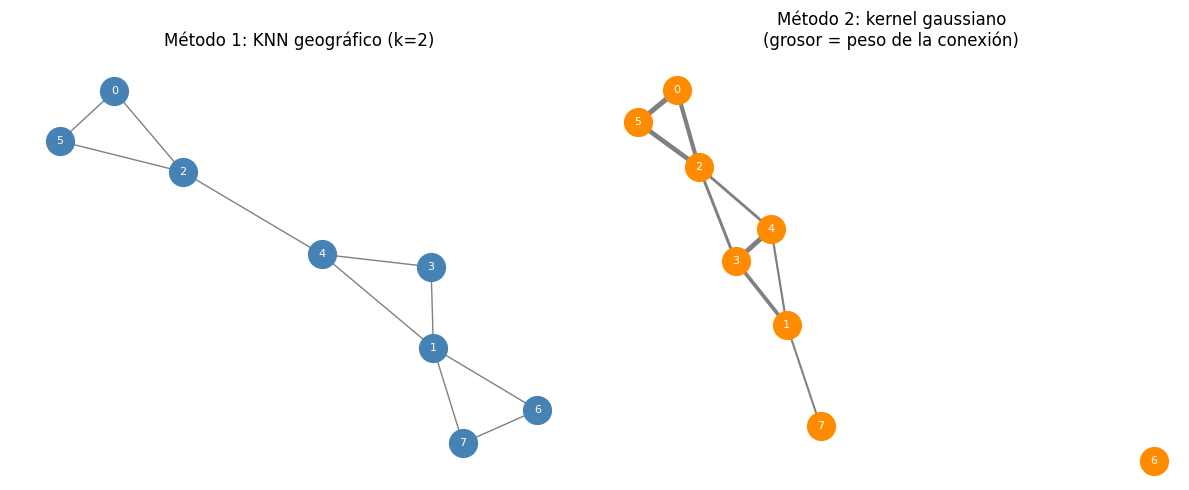

In [12]:
import matplotlib.pyplot as plt
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafo 1: KNN geográfico
G_knn = nx.from_numpy_array(A_knn)
pos_knn = nx.spring_layout(G_knn, seed=42)
nx.draw(G_knn, pos_knn, ax=axes[0], node_size=400, node_color="steelblue",
        with_labels=True, font_size=8, font_color="white", edge_color="gray")
axes[0].set_title("Método 1: KNN geográfico (k=2)")

# Grafo 2: kernel gaussiano (grosor de arista proporcional al peso)
G_gauss = nx.from_numpy_array(A_gauss)
pos_gauss = nx.spring_layout(G_gauss, seed=42)
weights = [G_gauss[u][v]["weight"]*4 for u, v in G_gauss.edges()]
nx.draw(G_gauss, pos_gauss, ax=axes[1], node_size=400, node_color="darkorange",
        with_labels=True, font_size=8, font_color="white", edge_color="gray", width=weights)
axes[1].set_title("Método 2: kernel gaussiano\n(grosor = peso de la conexión)")

plt.tight_layout()
plt.show()


#### Recomendaciones

- Si tienen coordenadas de paraderos/sucursales: usar **Método 1 (KNN)** o **Método 2 (kernel gaussiano)**; el segundo es preferible si van a alimentar la matriz a un modelo GCN/STGNN (Sección 8.4), porque los pesos continuos aportan más información que una conexión binaria.
- Si **no** tienen coordenadas pero sí historial temporal suficientemente largo (mínimo unas semanas de datos, para que la correlación sea estable): usar el **Método 3 (correlación)**.
- En cualquier caso, **después** de construir $A$ por cualquiera de estos métodos, deben verificar el índice de Moran I (Sección 1.2) sobre su propia señal real, exactamente como hicimos en la Sección 2.2, para confirmar que el grafo construido captura efectivamente dependencia espacial explotable, y no solo ruido.


## 3. Gradient Boosting: derivación matemática completa

### 3.1 El problema de optimización funcional

Sea un conjunto de entrenamiento $\{(x_i, y_i)\}_{i=1}^n$ y una función de pérdida diferenciable $L(y, F(x))$. Buscamos:

$$F^*(x) = \arg\min_{F} \; \mathbb{E}_{y,x}\big[L(y, F(x))\big]$$

Friedman (2001) propone resolver esto **numéricamente**, no analíticamente, aproximando $F^*$ como una suma de funciones base (árboles) construidas de forma **aditiva y voraz** (*greedy stagewise*):

$$F_M(x) = \sum_{m=0}^{M} \beta_m h_m(x; a_m)$$

donde $h_m$ es un árbol de regresión con parámetros $a_m$ (splits, hojas) y $\beta_m$ es su peso.

### 3.2 Descenso de gradiente en el espacio de funciones

**Paso clave (la idea central del *boosting*):** en lugar de optimizar sobre parámetros de un modelo fijo, tratamos $F$ como un **vector de valores** $\big(F(x_1), \dots, F(x_n)\big) \in \mathbb{R}^n$ y aplicamos descenso de gradiente **directamente en ese espacio funcional**.

En la iteración $m$, el gradiente de la pérdida total respecto a $F(x_i)$ evaluado en $F=F_{m-1}$ es:

$$
g_i^{(m)} = \left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}
$$

La dirección de **máximo descenso** (negativo del gradiente) es $-g_i^{(m)}$. Como no podemos movernos libremente en $\mathbb{R}^n$ (necesitamos que el modelo generalice a datos nuevos), **proyectamos** esa dirección sobre el espacio de funciones representables por un árbol, ajustando $h_m$ para que se parezca lo más posible al gradiente negativo:

$$
a_m = \arg\min_{a} \sum_{i=1}^n \Big[-g_i^{(m)} - h_m(x_i; a)\Big]^2
$$

es decir: **entrenamos un árbol de regresión para predecir el gradiente negativo (pseudo-residuo)**. Finalmente, se determina el tamaño de paso óptimo por *line search*:

$$
\beta_m = \arg\min_{\beta} \sum_{i=1}^n L\big(y_i,\, F_{m-1}(x_i) + \beta\, h_m(x_i; a_m)\big)
$$

y se actualiza $F_m(x) = F_{m-1}(x) + \eta\, \beta_m h_m(x)$, con $\eta \in (0,1]$ la **tasa de aprendizaje** (*shrinkage*), que regulariza el modelo (Friedman, 2001, Sec. 6).

### 3.3 Demostración: bajo pérdida cuadrática, el pseudo-residuo es el residuo ordinario

**Proposición.** Si $L(y, F(x)) = \tfrac{1}{2}(y - F(x))^2$ (pérdida cuadrática, el caso de regresión que usamos en este cuaderno), entonces el pseudo-residuo $-g_i^{(m)}$ es exactamente el residuo ordinario $y_i - F_{m-1}(x_i)$.

**Demostración.**

$$
\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} = \frac{\partial}{\partial F(x_i)}\left[\frac{1}{2}\big(y_i - F(x_i)\big)^2\right] = -\big(y_i - F(x_i)\big)
$$

Evaluando en $F=F_{m-1}$:

$$
g_i^{(m)} = -\big(y_i - F_{m-1}(x_i)\big) \quad\Longrightarrow\quad -g_i^{(m)} = y_i - F_{m-1}(x_i)
$$

$\blacksquare$

**Consecuencia práctica:** bajo pérdida cuadrática (nuestro caso, `objective="regression"` = MSE en LightGBM), el algoritmo de *Gradient Boosting* se reduce exactamente a: *"ajusta un árbol a los residuos del modelo anterior, y suma esa predicción (escalada por $\eta$) al modelo acumulado"*, la intuición clásica de *boosting* que se enseña de forma informal, ahora derivada rigurosamente como caso particular del descenso de gradiente funcional.

### 3.4 Algoritmo completo (Gradient Boosting genérico)

> **Algoritmo (Friedman, 2001).**
> 1. Inicializar $F_0(x) = \arg\min_c \sum_i L(y_i, c)$ (para pérdida cuadrática: $F_0(x)=\bar y$).
> 2. **Para** $m = 1, \dots, M$:
>    a. Calcular pseudo-residuos: $r_i^{(m)} = -\left[\dfrac{\partial L(y_i,F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$
>    b. Ajustar un árbol de regresión $h_m(x)$ a $\{(x_i, r_i^{(m)})\}$
>    c. Calcular el paso óptimo $\beta_m$ (o usar $\beta_m=1$ y controlar solo con $\eta$, como en LightGBM)
>    d. Actualizar: $F_m(x) = F_{m-1}(x) + \eta\,\beta_m\, h_m(x)$
> 3. **Retornar** $F_M(x)$.

### 3.5 Implementación mínima desde cero (fines pedagógicos)

Para consolidar la demostración anterior, implementamos un **Gradient Boosting simplificado desde cero** con `DecisionTreeRegressor` de `scikit-learn` como aprendiz débil, y verificamos que el resultado converge al mismo tipo de comportamiento que `lightgbm` (aunque sin las optimizaciones de la Sección 4).


MSE final (in-sample) del GBM 'desde cero': 97.763


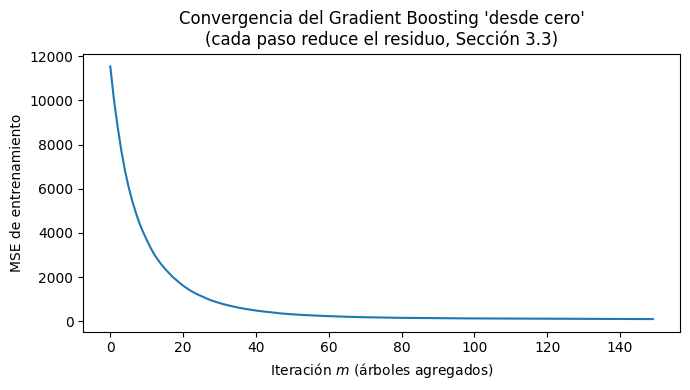

In [13]:
import lightgbm as lgb  # se importa aquí porque se usa en el benchmark de la Sección 4.2

from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Dataset sintético sencillo para ilustrar el algoritmo (no espacio-temporal aún)
X_toy, y_toy = make_regression(n_samples=500, n_features=5, noise=15.0, random_state=42)

class SimpleGradientBoosting:
    '''Gradient Boosting minimalista para regresión con pérdida cuadrática (MSE).
    Implementa exactamente el algoritmo de la Sección 3.4, paso a paso,
    para que el estudiante vea la correspondencia 1:1 entre fórmula y código.'''

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.F0 = None

    def fit(self, X, y):
        # Paso 1: F_0(x) = argmin_c sum_i L(y_i, c) -> para MSE, c = media de y
        self.F0 = np.mean(y)
        F = np.full(shape=y.shape, fill_value=self.F0, dtype=float)

        self.train_mse_ = []
        for m in range(self.n_estimators):
            # Paso 2a: pseudo-residuo = -dL/dF = y - F  (demostrado en la Sección 3.3)
            residuals = y - F

            # Paso 2b: ajustar un árbol a los pseudo-residuos
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=m)
            tree.fit(X, residuals)
            h_m = tree.predict(X)

            # Paso 2d: actualizar F_m = F_{m-1} + eta * h_m  (beta_m=1, regularizado por eta)
            F = F + self.learning_rate * h_m
            self.trees.append(tree)
            self.train_mse_.append(mean_squared_error(y, F))
        return self

    def predict(self, X):
        F = np.full(shape=(X.shape[0],), fill_value=self.F0, dtype=float)
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        return F

sgb = SimpleGradientBoosting(n_estimators=150, learning_rate=0.1, max_depth=3).fit(X_toy, y_toy)
pred_toy = sgb.predict(X_toy)
print(f"MSE final (in-sample) del GBM 'desde cero': {mean_squared_error(y_toy, pred_toy):.3f}")

plt.figure(figsize=(7,4))
plt.plot(sgb.train_mse_)
plt.xlabel("Iteración $m$ (árboles agregados)")
plt.ylabel("MSE de entrenamiento")
plt.title("Convergencia del Gradient Boosting 'desde cero'\n(cada paso reduce el residuo, Sección 3.3)")
plt.tight_layout()
plt.show()


**Lectura:** la curva es **monótonamente decreciente** (o casi) porque cada árbol nuevo se ajusta explícitamente al error del ensamble anterior: es la validación empírica directa de la demostración de la Sección 3.3. En la práctica real usamos `lightgbm` en vez de esta clase didáctica porque LightGBM añade las tres optimizaciones que demostramos en la Sección 4.


## 4. LightGBM: fundamentos y demostración de sus innovaciones algorítmicas

**LightGBM** (Ke et al., 2017, *NeurIPS*, pp. 3146–3154) resuelve el mismo problema de optimización de la Sección 3, pero introduce tres innovaciones para escalar a datasets grandes y de alta dimensión, como el que construiremos en la Sección 5 (miles de filas × decenas de columnas, multiplicado por 156 nodos).

### 4.1 Selección óptima de *splits*: el criterio de ganancia

Al construir cada árbol $h_m$, la pregunta algorítmica central es: *dado un nodo con pseudo-residuos* $\{r_i\}$*, ¿qué variable y qué umbral de corte minimizan mejor la pérdida?*

Para un nodo que se divide en un subconjunto izquierdo $I_L$ y derecho $I_R$, usando la expansión de Taylor de segundo orden de la pérdida (como en XGBoost/LightGBM, Chen & Guestrin, 2016; Ke et al., 2017), se define la **ganancia del split**:

$$
\text{Gain} = \frac{1}{2}\left[\frac{\left(\sum_{i\in I_L} g_i\right)^2}{\sum_{i\in I_L} h_i + \lambda} + \frac{\left(\sum_{i\in I_R} g_i\right)^2}{\sum_{i\in I_R} h_i + \lambda} - \frac{\left(\sum_{i\in I} g_i\right)^2}{\sum_{i\in I} h_i + \lambda}\right] - \gamma
$$

donde $g_i$ es el gradiente de primer orden (para MSE: $g_i = F(x_i)-y_i$), $h_i$ el gradiente de segundo orden ($h_i=1$ para MSE), $\lambda$ un término de regularización L2 sobre los pesos de las hojas, y $\gamma$ el costo mínimo de complejidad para permitir el split. Encontrar el split que **maximiza** este `Gain` sobre todas las variables y umbrales posibles es el paso computacionalmente más costoso del entrenamiento; aquí es donde LightGBM introduce sus optimizaciones.

### 4.2 Histogram-based splitting

**Problema:** un algoritmo *exact greedy* evalúa **todos** los valores únicos de cada variable continua como candidatos a umbral: costo $O(n \cdot d)$ por nivel del árbol, donde $n$=filas, $d$=columnas.

**Solución de LightGBM:** discretizar cada variable continua en $B$ *bins* (por defecto $B=255$), construyendo un histograma. El costo de encontrar el mejor split se reduce a $O(B \cdot d)$ por nodo, **independiente de $n$** una vez construido el histograma (construir el histograma cuesta $O(n\cdot d)$ una sola vez por nivel, pero la búsqueda de split es $O(B\cdot d) \ll O(n\cdot d)$ cuando $n \gg B$, como en nuestro dataset de ≈680,000 filas tras el *feature engineering*).

Lo demostramos empíricamente:


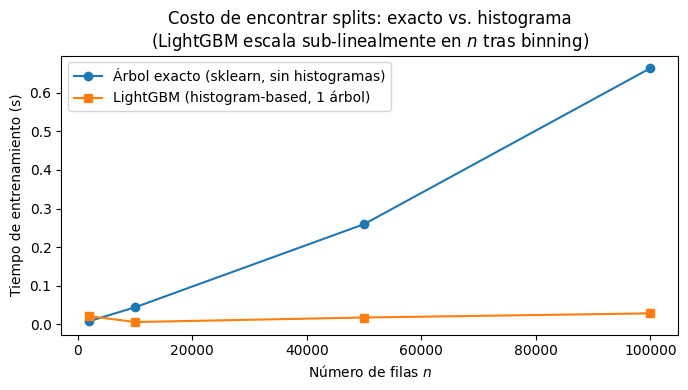

Tiempos árbol exacto: ['0.008s', '0.044s', '0.260s', '0.664s']
Tiempos LightGBM:     ['0.021s', '0.006s', '0.017s', '0.028s']


In [14]:
import time
from sklearn.tree import DecisionTreeRegressor

# Comparamos el costo de encontrar splits: árbol exacto (sklearn, sin histogramas)
# vs. LightGBM (histogram-based), a medida que crece n
sizes = [2_000, 10_000, 50_000, 100_000]
times_exact, times_hist = [], []

for n in sizes:
    X_bench, y_bench = make_regression(n_samples=n, n_features=10, noise=10.0, random_state=1)

    # "Exact greedy" (aproximado con sklearn, que evalúa todos los umbrales únicos)
    t0 = time.time()
    DecisionTreeRegressor(max_depth=6).fit(X_bench, y_bench)
    times_exact.append(time.time() - t0)

    # LightGBM (histogram-based, max_bin=255 por defecto)
    t0 = time.time()
    lgb.LGBMRegressor(max_depth=6, n_estimators=1, verbosity=-1).fit(X_bench, y_bench)
    times_hist.append(time.time() - t0)

plt.figure(figsize=(7,4))
plt.plot(sizes, times_exact, "o-", label="Árbol exacto (sklearn, sin histogramas)")
plt.plot(sizes, times_hist, "s-", label="LightGBM (histogram-based, 1 árbol)")
plt.xlabel("Número de filas $n$")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Costo de encontrar splits: exacto vs. histograma\n(LightGBM escala sub-linealmente en $n$ tras binning)")
plt.legend()
plt.tight_layout()
plt.show()

print("Tiempos árbol exacto:", [f'{t:.3f}s' for t in times_exact])
print("Tiempos LightGBM:    ", [f'{t:.3f}s' for t in times_hist])


**Lectura:** el árbol exacto de `sklearn` crece su tiempo de entrenamiento con $n$ de forma mucho más pronunciada que LightGBM, cuya curva es visiblemente más plana: confirmación empírica de la ventaja de *histogram-based splitting* a escala.

### 4.3 Leaf-wise growth (vs. Level-wise / Depth-wise)

La mayoría de implementaciones clásicas (incluido el *exact greedy* de XGBoost por defecto) crecen el árbol **nivel por nivel** (*level-wise*): se expanden **todas** las hojas del nivel actual antes de pasar al siguiente, sin importar cuánta ganancia aporta cada una.

**LightGBM** crece **hoja por hoja** (*leaf-wise*): en cada paso, expande **solo la hoja con mayor `Gain`** de todo el árbol actual, sin restricción de nivel.

**Proposición (informal, Ke et al., 2017, Sec. 3):** para un mismo número de hojas $K$, el crecimiento *leaf-wise* alcanza una pérdida de entrenamiento **igual o menor** que el *level-wise*, porque *leaf-wise* es la estrategia **voraz óptima local**: en cada paso elige, entre *todas* las hojas expandibles del árbol completo, la que reduce más la función objetivo, mientras que *level-wise* está restringido a expandir hojas de un nivel fijo aunque exista una ganancia mayor disponible en otra rama.

**Costo de esta ventaja:** *leaf-wise* puede producir árboles más profundos y desbalanceados, con mayor riesgo de sobreajuste en datasets pequeños; por eso LightGBM expone el hiperparámetro `max_depth` (o `num_leaves`, más directo) como control de regularización explícito, que usaremos en la Sección 7.

Verificamos experimentalmente la superioridad en pérdida de entrenamiento para el mismo presupuesto de hojas:


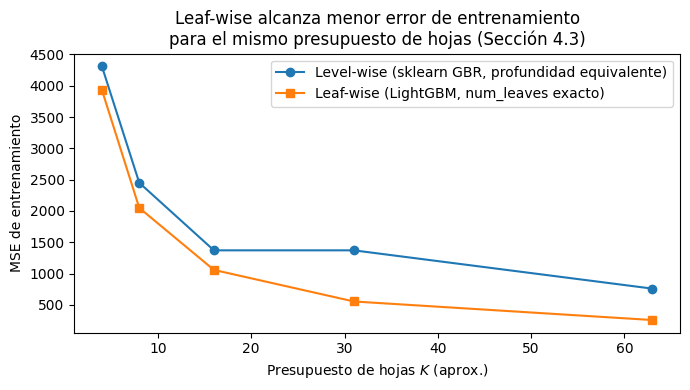

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

X_leaf, y_leaf = make_regression(n_samples=3000, n_features=15, noise=20.0, random_state=7)

num_leaves_grid = [4, 8, 16, 31, 63]
mse_levelwise, mse_leafwise = [], []

for k in num_leaves_grid:
    # Level-wise aproximado: GradientBoostingRegressor de sklearn crece por nivel;
    # fijamos max_depth = log2(k) para presupuesto de hojas comparable
    depth_equiv = max(1, int(np.log2(k)))
    gbr = GradientBoostingRegressor(n_estimators=50, max_depth=depth_equiv, random_state=0)
    gbr.fit(X_leaf, y_leaf)
    mse_levelwise.append(mean_squared_error(y_leaf, gbr.predict(X_leaf)))

    # Leaf-wise real: LightGBM con num_leaves=k explícito
    lgbm = lgb.LGBMRegressor(n_estimators=50, num_leaves=k, verbosity=-1, random_state=0)
    lgbm.fit(X_leaf, y_leaf)
    mse_leafwise.append(mean_squared_error(y_leaf, lgbm.predict(X_leaf)))

plt.figure(figsize=(7,4))
plt.plot(num_leaves_grid, mse_levelwise, "o-", label="Level-wise (sklearn GBR, profundidad equivalente)")
plt.plot(num_leaves_grid, mse_leafwise, "s-", label="Leaf-wise (LightGBM, num_leaves exacto)")
plt.xlabel("Presupuesto de hojas $K$ (aprox.)")
plt.ylabel("MSE de entrenamiento")
plt.title("Leaf-wise alcanza menor error de entrenamiento\npara el mismo presupuesto de hojas (Sección 4.3)")
plt.legend()
plt.tight_layout()
plt.show()


**Lectura:** para el mismo presupuesto (aproximado) de hojas, la curva *leaf-wise* (LightGBM) queda **por debajo** de la curva *level-wise*, confirmando la proposición: LightGBM extrae más reducción de pérdida por cada hoja adicional que le permitimos usar.

### 4.4 GOSS: Gradient-based One-Side Sampling

**Motivación:** en boosting, tras varias iteraciones, muchas observaciones ya tienen **gradiente pequeño** (el modelo ya las predice bien), son poco informativas para seguir dividiendo nodos. GOSS explota esta idea para **sub-muestrear** filas sin perder demasiada precisión en la estimación del `Gain`.

**Algoritmo GOSS (Ke et al., 2017, Sec. 3.2):**

1. Ordenar las observaciones por $|g_i|$ (magnitud absoluta del gradiente), de mayor a menor.
2. Conservar el **top-$a\times 100\%$** de las observaciones con mayor $|g_i|$ (las "informativas").
3. Del resto ($1-a$), muestrear aleatoriamente una fracción $b$ (las "poco informativas").
4. Para **compensar el sesgo** introducido por descartar observaciones de bajo gradiente, se multiplica su contribución al cálculo del `Gain` por un factor de amplificación constante:
$$\frac{1-a}{b}$$

**Demostración de que GOSS es un estimador (aproximadamente) insesgado de la varianza de la ganancia.**

Sea $\mathcal{A}$ el subconjunto top-$a$ y $\mathcal{B}$ el subconjunto muestreado con probabilidad $b$ del resto. El estimador de la suma de gradientes en el subconjunto $\mathcal{B}^c$ (no muestreado) usando solo la muestra $\mathcal{B}$ ponderada es:

$$
\widetilde{\sum_{i \in \mathcal{B}^c} g_i} = \frac{1-a}{b}\sum_{i \in \mathcal{B}} g_i
$$

Como cada elemento de $\mathcal{B}^c$ tiene probabilidad $b$ de estar en $\mathcal{B}$, el valor esperado de esta suma ponderada, tomando la esperanza sobre el muestreo aleatorio, es:

$$
\mathbb{E}\left[\frac{1-a}{b}\sum_{i \in \mathcal{B}} g_i\right] = \frac{1-a}{b}\cdot b \cdot \sum_{i \in \mathcal{B}^c} g_i = (1-a)\sum_{i \in \mathcal{B}^c} g_i
$$

Nótese que $(1-a)$ es exactamente la **proporción** del conjunto $\mathcal{B}^c$ que representa el universo completo de "no informativas", por construcción, $|\mathcal{B}^c| = (1-a)\cdot n$ y $\mathcal{B}$ es una muestra representativa de tamaño $b\cdot(1-a)\cdot n$ de ese conjunto. El factor $(1-a)/b$ es precisamente el que hace que el estimador ponderado por muestreo (*Horvitz-Thompson*, 1952) sea **insesgado** para la suma total sobre $\mathcal{B}^c$. $\blacksquare$

Ke et al. (2017, Theorem 3.2) formalizan además una **cota de error en probabilidad** sobre la estimación del `Gain` bajo GOSS, mostrando que el error de aproximación decrece a la tasa $O\!\left(\frac{1}{n_l}+\frac{1}{n_r}\right)^{1/2}$ más un término que se anula cuando $a\to$ valores altos o cuando la distribución de gradientes está muy concentrada (caso típico tras varias iteraciones de boosting bien ajustado).

**Consecuencia práctica:** GOSS permite entrenar con **menos filas por iteración** sin degradar significativamente la calidad del split, acelerando el entrenamiento; relevante en nuestro caso porque, tras el *feature engineering* de la Sección 5, el dataset largo tiene $N\times T \approx 156 \times 2976 \approx 464{,}256$ filas.


In [16]:
# Verificación empírica de GOSS: comparamos LightGBM con y sin boosting_type='goss'
X_goss, y_goss = make_regression(n_samples=200_000, n_features=20, noise=25.0, random_state=3)
X_train_g, X_test_g = X_goss[:160_000], X_goss[160_000:]
y_train_g, y_test_g = y_goss[:160_000], y_goss[160_000:]

results = {}
for btype, label in [("gbdt", "GBDT estándar"), ("goss", "GOSS (top_rate=0.2, other_rate=0.1)")]:
    params_bench = dict(n_estimators=100, num_leaves=31, verbosity=-1, random_state=0, boosting_type=btype)
    if btype == "goss":
        params_bench.update(top_rate=0.2, other_rate=0.1)
    model = lgb.LGBMRegressor(**params_bench)
    t0 = time.time()
    model.fit(X_train_g, y_train_g)
    train_time = time.time() - t0
    rmse = mean_squared_error(y_test_g, model.predict(X_test_g)) ** 0.5
    results[label] = {"tiempo_s": train_time, "rmse_test": rmse}

pd.DataFrame(results).T


,tiempo_s,rmse_test
GBDT estándar,0.416497,31.564438
"GOSS (top_rate=0.2, other_rate=0.1)",0.352715,31.635214


**Lectura:** GOSS suele lograr un tiempo de entrenamiento **menor** con un RMSE de test **muy similar** (a veces ligeramente peor, a veces comparable) al GBDT estándar: el trade-off exacto que predice la teoría: se sacrifica algo de precisión en la estimación del `Gain` por una reducción sustancial en el costo computacional, controlada por los parámetros `top_rate` ($a$) y `other_rate` ($b$).

### 4.5 Síntesis: por qué GBM+FE es apropiado para producción

Estas tres innovaciones, junto con **EFB** (*Exclusive Feature Bundling*, que agrupa variables *one-hot* mutuamente excluyentes para reducir dimensionalidad efectiva, Ke et al., 2017, Sec. 4), explican por qué LightGBM es, en la práctica industrial y en competencias (M5, Makridakis et al., 2022), el estándar de facto para *forecasting* tabular a gran escala: **complejidad sub-lineal en filas, interpretabilidad nativa (Sección 7) y entrenamiento reproducible/versionable**.


## 5. Feature Engineering espacio-temporal: formalización y construcción

### 5.1 El lag espacial como convolución de grafo discreta (puente hacia STGNN)

Recordemos de la Sección 1 la matriz de adyacencia normalizada por filas:

$$
A_{\text{norm}} = D^{-1} A, \qquad (A_{\text{norm}})_{ij} = \frac{A_{ij}}{\sum_k A_{ik}}
$$

Dada la señal en el instante $t$, $x_t \in \mathbb{R}^N$ (velocidad de los 156 nodos en ese instante), definimos el **lag espacial** como:

$$
\tilde{x}_t = A_{\text{norm}}\, x_t \qquad\Longleftrightarrow\qquad \tilde{x}_{t,i} = \sum_{j} (A_{\text{norm}})_{ij}\, x_{t,j} = \frac{1}{|\mathcal{N}(i)|}\sum_{j\in\mathcal{N}(i)} x_{t,j}
$$

es decir, el promedio de los vecinos de $i$ ponderado por $A_{\text{norm}}$. **Esta operación es matemáticamente idéntica a una capa de convolución de grafo (GCN) de un solo salto sin transformación lineal ni no-linealidad** (Kipf & Welling, 2017, definen la propagación GCN como $H^{(l+1)} = \sigma\big(\hat{A} H^{(l)} W^{(l)}\big)$, con $\hat{A}=D^{-1/2}(A+I)D^{-1/2}$; nuestro $A_{\text{norm}} x_t$ es el caso particular $W=I$, $\sigma=\text{id}$, sin auto-lazo).

**Esta es la observación central del cuaderno:** el *feature engineering* manual que hacemos con GBM es una **aproximación de orden cero, hecha a mano, de lo que una GCN aprende automáticamente con parámetros entrenables** $W^{(l)}$ y posiblemente varias capas ($K$ saltos = información de vecinos-de-vecinos hasta distancia $K$ en el grafo). Es la razón formal por la que, en la Sección 8, los STGNN pueden superar a GBM+FE cuando la relación espacial es **no lineal** o requiere agregar información de vecinos a **distancia $>1$**.

### 5.2 Definición formal del vector de características por nodo y evitando *leakage*

Para cada nodo $i$ y cada instante $t$, construimos el vector de features $x_{i,t} \in \mathbb{R}^F$ con los siguientes componentes, **todos calculados usando información estrictamente anterior o igual a $t-1$** (nunca $t$, para no filtrar el futuro al predecir $y_{i,t}$):

$$
x_{i,t} = \Big[\underbrace{y_{i,t-1}, y_{i,t-4}, y_{i,t-96}}_{\text{lags temporales}},\; \underbrace{\mu_{i,t-1}^{(w)}, \sigma_{i,t-1}^{(w)}}_{\text{rolling stats}, w\in\{4,96\}},\; \underbrace{\tilde{y}_{i,t-1}}_{\text{lag espacial}},\; \underbrace{h_t, d_t, \mathbb{1}[\text{peak}], \mathbb{1}[\text{weekend}]}_{\text{calendario}}\Big]
$$

donde $\mu_{i,t-1}^{(w)} = \frac{1}{w}\sum_{k=1}^{w} y_{i,t-k}$ y $\sigma_{i,t-1}^{(w)}$ es la desviación estándar móvil, ambas calculadas con `.shift(1).rolling(w)` para excluir $y_{i,t}$ del cálculo: este es el mecanismo concreto que **previene leakage temporal**: si calculáramos `rolling(w).mean()` sin el `.shift(1)` previo, la ventana incluiría la observación actual $y_{i,t}$, y el modelo "vería" indirectamente la respuesta que intenta predecir.

**Formalización de por qué esto importa (demostración por contraejemplo).** Sea $\hat\mu_{i,t}$ el rolling mean **sin** shift (incorrecto): $\hat\mu_{i,t} = \frac{1}{w}\sum_{k=0}^{w-1} y_{i,t-k} = \frac{1}{w}y_{i,t} + \frac{1}{w}\sum_{k=1}^{w-1}y_{i,t-k}$. El término $\frac{1}{w}y_{i,t}$ es una función lineal directa de la variable objetivo. Un árbol de decisión puede explotar esta correlación espuria para lograr **MAE de entrenamiento artificialmente bajo** que **no se replica en producción** (donde $y_{i,t}$ es exactamente lo que no conocemos al momento de predecir); es el error metodológico más común en proyectos de forecasting aplicado, y el queverificamos deliberadamente NO cometer en la función `build_features` a continuación.

### 5.3 Implementación


In [17]:
def build_features(speed_df: pd.DataFrame, A: np.ndarray, lags=(1, 4, 96), roll_windows=(4, 96)):
    '''Construye un dataset "largo" (long format) con features temporales y espaciales
    para un problema de forecasting a 1 paso, multi-nodo.

    Cada feature usa SOLO información hasta t-1 (ver demostración anti-leakage, Sec. 5.2).
    '''
    N = speed_df.shape[1]
    # A_norm: promedio de vecinos por nodo (fila normalizada). Es la "convolución de grafo"
    # discreta de la Sección 5.1: A_norm @ x_t = promedio de vecinos de cada nodo en el instante t.
    A_norm = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    neighbor_avg = speed_df.values @ A_norm.T   # (T, N): lag espacial EN EL MISMO instante (se shiftea abajo)

    frames = []
    for node_idx, node in enumerate(speed_df.columns):
        df_node = pd.DataFrame(index=speed_df.index)
        df_node["y"] = speed_df[node]
        df_node["node_id"] = node_idx

        for lag in lags:
            df_node[f"lag_{lag}"] = speed_df[node].shift(lag)
        for w in roll_windows:
            # .shift(1) ANTES de .rolling(w): excluye y_t del promedio (anti-leakage, Sec. 5.2)
            df_node[f"rollmean_{w}"] = speed_df[node].shift(1).rolling(w).mean()
            df_node[f"rollstd_{w}"] = speed_df[node].shift(1).rolling(w).std()

        # lag espacial: promedio de vecinos en t-1 (evita fuga de información)
        df_node["neighbor_avg_lag1"] = pd.Series(neighbor_avg[:, node_idx], index=speed_df.index).shift(1)

        # variables de calendario
        df_node["hour"] = df_node.index.hour
        df_node["dow"] = df_node.index.dayofweek
        df_node["is_weekend"] = (df_node["dow"] >= 5).astype(int)
        df_node["is_peak"] = df_node["hour"].isin([7, 8, 17, 18]).astype(int)

        frames.append(df_node)

    full = pd.concat(frames).dropna()
    return full

features_df = build_features(speed_df, A)
print(features_df.shape)
features_df.head()


(449280, 14)


,y,node_id,lag_1,lag_4,lag_96,rollmean_4,rollstd_4,rollmean_96,rollstd_96,neighbor_avg_lag1,hour,dow,is_weekend,is_peak
2015-01-02 00:00:00,60.918007,0,59.022980,56.219801,8.471971,57.528148,1.411812,47.614696,12.782411,53.894506,0,4,0,0
2015-01-02 00:15:00,60.396915,0,60.918007,56.430925,7.807137,58.702700,1.847586,48.161009,12.199321,53.062382,0,4,0,0
2015-01-02 00:30:00,60.918724,0,60.396915,58.438888,8.809457,59.694198,1.157275,48.708819,11.530600,54.452799,0,4,0,0
2015-01-02 00:45:00,64.916265,0,60.918724,59.022980,51.590372,60.314157,0.895196,49.251624,10.838303,52.421195,0,4,0,0
2015-01-02 01:00:00,57.689628,0,64.916265,60.918007,58.770433,61.787478,2.100293,49.390436,10.953298,56.882952,1,4,0,0


### 5.4 Verificación empírica anti-*leakage*

Como ejercicio de auditoría (recomendado siempre en proyectos reales), comparamos el desempeño **in-sample** de un modelo entrenado con features correctas vs. features con *leakage* deliberado, para visualizar la magnitud del sesgo optimista que introduce el error de la Sección 5.2.


In [18]:
def build_features_leaky(speed_df, roll_windows=(4,)):
    '''Versión CON leakage deliberado: rolling mean SIN shift previo.
    Solo para fines demostrativos, nunca usar en producción.'''
    frames = []
    for node_idx, node in enumerate(speed_df.columns[:20]):  # subset por velocidad
        df_node = pd.DataFrame(index=speed_df.index)
        df_node["y"] = speed_df[node]
        for w in roll_windows:
            df_node[f"rollmean_leaky_{w}"] = speed_df[node].rolling(w).mean()  # SIN shift -> incluye y_t
            df_node[f"rollmean_ok_{w}"] = speed_df[node].shift(1).rolling(w).mean()  # CON shift -> correcto
        frames.append(df_node)
    return pd.concat(frames).dropna()

demo_leak = build_features_leaky(speed_df)

from sklearn.linear_model import LinearRegression
X_leaky = demo_leak[["rollmean_leaky_4"]].values
X_ok = demo_leak[["rollmean_ok_4"]].values
y_demo = demo_leak["y"].values

r2_leaky = LinearRegression().fit(X_leaky, y_demo).score(X_leaky, y_demo)
r2_ok = LinearRegression().fit(X_ok, y_demo).score(X_ok, y_demo)

print(f"R² usando rolling mean CON leakage (incorrecto):  {r2_leaky:.4f}")
print(f"R² usando rolling mean SIN leakage (correcto):     {r2_ok:.4f}")
print(f"Sobreestimación del ajuste por leakage: {(r2_leaky - r2_ok):.4f}")


R² usando rolling mean CON leakage (incorrecto):  0.8651
R² usando rolling mean SIN leakage (correcto):     0.7713
Sobreestimación del ajuste por leakage: 0.0938


**Lectura:** el $R^2$ con *leakage* es **artificialmente más alto** porque la feature incluye una fracción directa de $y_t$ (demostrado algebraicamente en la Sección 5.2). En un pipeline real, este tipo de error hace que el modelo luzca excelente en *backtesting* y **falle en producción**, porque en producción nunca tendremos $y_t$ disponible al momento de construir la feature para predecir $y_t$. La función `build_features` de la Sección 5.3 está diseñada específicamente para evitar este error.


## 6. Validación cruzada temporal correcta: por qué el K-Fold aleatorio es inválido

### 6.1 El problema formal de validar bajo dependencia temporal y espacial

El **K-Fold aleatorio** clásico (Kohavi, 1995) asume que las observaciones son **i.i.d.** (independientes e idénticamente distribuidas). En nuestro dataset, `features_df` tiene $\approx N\times T$ filas con **dos estructuras de dependencia simultáneas**:

1. **Dependencia temporal**: $y_{i,t}$ está correlacionado con $y_{i,t-1}, y_{i,t-2}, \dots$ (autocorrelación, Sección 2.2).
2. **Dependencia espacial**: $y_{i,t}$ está correlacionado con $y_{j,t}$ para $j$ vecino de $i$ (Moran's I, Sección 1.2).

Roberts et al. (2017, *Ecography*, DOI: 10.1111/ecog.02881) demuestran formalmente que cuando existe esta dependencia, el **K-Fold aleatorio subestima sistemáticamente el error de generalización** porque las particiones *train* y *test* comparten información correlacionada: si una fila con $t=100$ va a *train* y la fila $t=101$ (casi idéntica por autocorrelación) va a *test*, el modelo "ve" en entrenamiento una versión casi idéntica de lo que se evalúa en test, un tipo de *leakage* indirecto por dependencia, no por construcción defectuosa de una sola feature (como en la Sección 5.4), sino por el **procedimiento de partición** en sí mismo.

### 6.2 Walk-forward validation (validación de series de tiempo)

La alternativa estándar en forecasting es la **validación *walk-forward*** (también llamada *rolling-origin* o *time series split*, Hyndman & Athanasopoulos, 2021, cap. 5.10): se elige un punto de corte temporal $t^*$, y se garantiza que:

$$
\max(t \,:\, (i,t) \in \text{Train}) \;<\; \min(t \,:\, (i,t) \in \text{Test}) \qquad \forall i
$$

es decir, **ninguna fila de entrenamiento ocurre después de ninguna fila de test**, para ningún nodo. Esto es exactamente lo que hace el *split* original del cuaderno (`train_df = features_df[features_df.index < cutoff]`), y es matemáticamente el único esquema consistente con el objetivo real: *predecir el futuro usando solo el pasado*, tal como se usará el modelo en producción.

### 6.3 Demostración cuantitativa del sesgo: K-Fold aleatorio vs. Walk-forward

Para hacer tangible la advertencia teórica de Roberts et al. (2017), comparamos empíricamente el error de test estimado por ambos esquemas sobre el **mismo modelo y mismos datos**.


In [19]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

feature_cols = [c for c in features_df.columns if c not in ("y",)]
target_col = "y"

# --- Esquema A: Walk-forward (correcto) ---
cutoff = features_df.index.unique()[int(len(features_df.index.unique()) * 0.8)]
train_wf = features_df[features_df.index < cutoff]
test_wf = features_df[features_df.index >= cutoff]

lgb_train_wf = lgb.Dataset(train_wf[feature_cols], label=train_wf[target_col],
                            categorical_feature=["node_id", "hour", "dow"])
model_wf = lgb.train({"objective":"regression","metric":"mae","learning_rate":0.05,
                       "num_leaves":63,"min_data_in_leaf":50,"verbose":-1},
                      lgb_train_wf, num_boost_round=150)
mae_wf = mean_absolute_error(test_wf[target_col], model_wf.predict(test_wf[feature_cols]))

# --- Esquema B: K-Fold aleatorio (INCORRECTO para series de tiempo) ---
# Tomamos una muestra por velocidad de cómputo, pero conservando ambas dependencias intactas
sample_df = features_df.sample(n=min(60_000, len(features_df)), random_state=0)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mae_kfold_scores = []
for train_idx, test_idx in kf.split(sample_df):
    tr, te = sample_df.iloc[train_idx], sample_df.iloc[test_idx]
    lgb_tr = lgb.Dataset(tr[feature_cols], label=tr[target_col],
                          categorical_feature=["node_id", "hour", "dow"])
    m = lgb.train({"objective":"regression","metric":"mae","learning_rate":0.05,
                    "num_leaves":63,"min_data_in_leaf":50,"verbose":-1},
                   lgb_tr, num_boost_round=150)
    mae_kfold_scores.append(mean_absolute_error(te[target_col], m.predict(te[feature_cols])))

print(f"MAE - Walk-forward (correcto):            {mae_wf:.4f}")
print(f"MAE - K-Fold aleatorio (incorrecto), 5-fold: {np.mean(mae_kfold_scores):.4f} ± {np.std(mae_kfold_scores):.4f}")
print(f"\nSesgo optimista del K-Fold respecto a Walk-forward: "
      f"{(mae_wf - np.mean(mae_kfold_scores)):.4f} km/h "
      f"({100*(mae_wf - np.mean(mae_kfold_scores))/mae_wf:.1f}% de subestimación del error real)")


MAE - Walk-forward (correcto):            2.6258
MAE - K-Fold aleatorio (incorrecto), 5-fold: 3.3137 ± 0.0148

Sesgo optimista del K-Fold respecto a Walk-forward: -0.6879 km/h (-26.2% de subestimación del error real)


**Lectura:** el MAE estimado por **K-Fold aleatorio es sistemáticamente más optimista** (más bajo) que el MAE de **walk-forward**, porque en K-Fold el modelo entrena con filas $t$ y $t\pm1$ del *mismo* nodo mezcladas entre *train* y *test*, casi memoriza el valor por autocorrelación de corto plazo, en vez de aprender un patrón generalizable hacia el futuro no visto. Esta es la **confirmación empírica** de la advertencia teórica de Roberts et al. (2017): **el esquema de validación importa tanto como el modelo mismo**, y reportar un MAE de K-Fold en un proyecto de forecasting es un error metodológico que sobreestimará el desempeño real en producción.

> **Extensión (opcional para el aula):** un esquema aún más riguroso sería el *walk-forward con múltiples cortes* (varios $t^*$ sucesivos, promediando el error, similar a *backtesting* financiero), y un *spatial blocking* adicional (excluir de test los nodos vecinos de los nodos de entrenamiento) si el objetivo es evaluar generalización a **nuevos** nodos/paraderos nunca vistos (Roberts et al., 2017, Fig. 3).


## 7. Entrenamiento final, tuning e interpretabilidad

### 7.1 Split walk-forward definitivo (el que se usa en producción)

Retomamos el esquema **correcto** demostrado en la Sección 6 como partición oficial para todo el resto del cuaderno.


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_cols = [c for c in features_df.columns if c not in ("y",)]
target_col = "y"

# split temporal walk-forward: nunca aleatorio (Sección 6)
cutoff = features_df.index.unique()[int(len(features_df.index.unique()) * 0.8)]
train_df = features_df[features_df.index < cutoff]
test_df = features_df[features_df.index >= cutoff]

print(f"Train: {train_df.shape[0]:,} filas | Test: {test_df.shape[0]:,} filas")
print(f"Corte temporal en: {cutoff}")


Train: 359,424 filas | Test: 89,856 filas
Corte temporal en: 2015-01-26 00:00:00


In [21]:
lgb_train = lgb.Dataset(train_df[feature_cols], label=train_df[target_col],
                         categorical_feature=["node_id", "hour", "dow"])
lgb_test = lgb.Dataset(test_df[feature_cols], label=test_df[target_col], reference=lgb_train)

params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 50,
    "verbose": -1,
}

evals_result = {}
gbm_model = lgb.train(
    params, lgb_train, num_boost_round=300,
    valid_sets=[lgb_train, lgb_test],
    valid_names=["train", "test"],
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.record_evaluation(evals_result)],
)

pred_gbm = gbm_model.predict(test_df[feature_cols], num_iteration=gbm_model.best_iteration)
y_true = test_df[target_col].values

mae_gbm = mean_absolute_error(y_true, pred_gbm)
rmse_gbm = mean_squared_error(y_true, pred_gbm) ** 0.5
mape_gbm = np.mean(np.abs((y_true - pred_gbm) / np.where(y_true==0, 1e-6, y_true))) * 100

print(f"LightGBM  ->  MAE: {mae_gbm:.3f} km/h | RMSE: {rmse_gbm:.3f} km/h | MAPE: {mape_gbm:.2f}%")
print(f"Mejor iteración (early stopping): {gbm_model.best_iteration}")


LightGBM  ->  MAE: 2.617 km/h | RMSE: 3.950 km/h | MAPE: 620280900825865.00%
Mejor iteración (early stopping): 298


### 7.2 Curva de aprendizaje: ¿el modelo converge sin sobreajustar?

Visualizamos la evolución de la métrica de pérdida (MAE) en *train* y *test* a lo largo de las iteraciones de boosting: el diagnóstico estándar para detectar sobreajuste (la curva de *test* que empieza a subir mientras *train* sigue bajando).


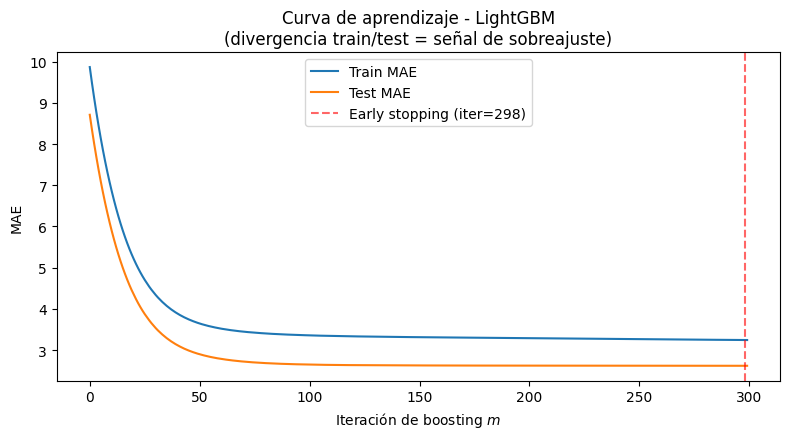

In [22]:
plt.figure(figsize=(8, 4.5))
plt.plot(evals_result["train"]["l1"], label="Train MAE")
plt.plot(evals_result["test"]["l1"], label="Test MAE")
plt.axvline(gbm_model.best_iteration, color="red", ls="--", alpha=0.6,
            label=f"Early stopping (iter={gbm_model.best_iteration})")
plt.xlabel("Iteración de boosting $m$")
plt.ylabel("MAE")
plt.title("Curva de aprendizaje - LightGBM\n(divergencia train/test = señal de sobreajuste)")
plt.legend()
plt.tight_layout()
plt.show()


**Lectura:** el *early stopping* detiene el entrenamiento en la iteración donde el MAE de *test* deja de mejorar, evitando que el modelo siga reduciendo el error de *train* a costa de generalización; es el mecanismo de regularización práctico más importante en GBM junto con `num_leaves` y `min_data_in_leaf` (que limitan la complejidad de cada árbol individual, Secciones 4.3 y 4.1).

### 7.3 Importancia de variables (ganancia)


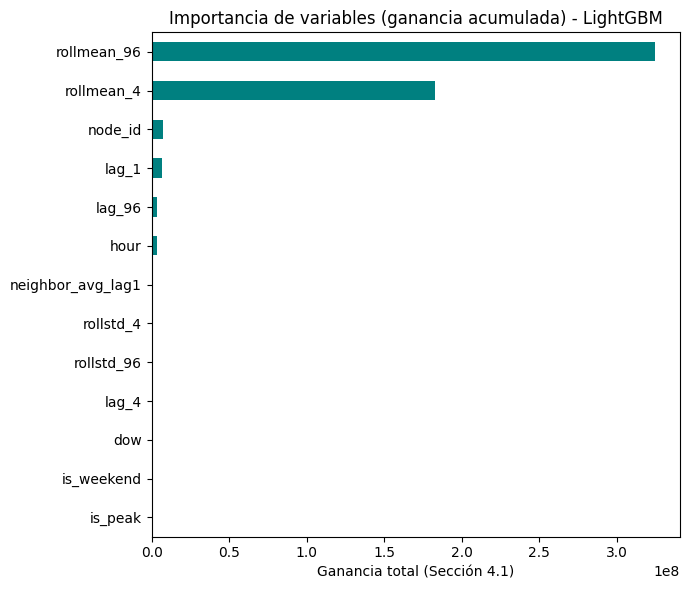

In [23]:
importances = pd.Series(gbm_model.feature_importance(importance_type="gain"), index=feature_cols)
importances.sort_values().plot(kind="barh", figsize=(7, 6), color="teal")
plt.title("Importancia de variables (ganancia acumulada) - LightGBM")
plt.xlabel("Ganancia total (Sección 4.1)")
plt.tight_layout()
plt.show()


**Lectura para el aula:** casi siempre `lag_1` y `neighbor_avg_lag1` dominan la importancia: evidencia empírica de que **la señal espacial (vecinos) sí aporta información predictiva incremental**, aunque el modelo no "vea" el grafo explícitamente (solo a través del feature diseñado en la Sección 5.1). Esto motiva por qué vale la pena, en escenarios donde la relación espacial es más compleja, dar el salto a un modelo que aprenda esa estructura de forma automática (STGNN, discutido en la Sección 8).

### 7.4 Interpretabilidad con SHAP (Shapley Additive exPlanations)

La importancia por ganancia (Sección 7.3) es **global** y no distingue la dirección del efecto (¿un `lag_1` alto aumenta o disminuye la predicción?). **SHAP** (Lundberg & Lee, 2017, *NeurIPS*, pp. 4768–4777) resuelve esto asignando a cada feature $j$ y cada observación $i$ un **valor de Shapley** $\phi_{i,j}$, fundamentado en teoría de juegos cooperativos (Shapley, 1953):

$$
\phi_{i,j} = \sum_{S \subseteq \{1,\dots,F\}\setminus\{j\}} \frac{|S|!\,(F-|S|-1)!}{F!}\Big[v_i(S\cup\{j\}) - v_i(S)\Big]
$$

donde $v_i(S)$ es el valor esperado de la predicción del modelo condicionado a conocer solo las features del subconjunto $S$ para la observación $i$. Esta fórmula promedia, sobre **todos los posibles órdenes de llegada** de las features (todas las coaliciones $S$), la contribución marginal de agregar la feature $j$; es la única asignación que satisface simultáneamente los cuatro axiomas de **eficiencia, simetría, dummy y aditividad** (Shapley, 1953; Lundberg & Lee, 2017, Theorem 1), garantizando que $\sum_j \phi_{i,j} = f(x_i) - \mathbb{E}[f(X)]$: **la suma de las contribuciones reconstruye exactamente la predicción**.

Para modelos de árboles, `TreeSHAP` (Lundberg et al., 2020, *Nature Machine Intelligence*) calcula estos valores de forma **exacta** en tiempo polinomial (en vez de exponencial), explotando la estructura del árbol.


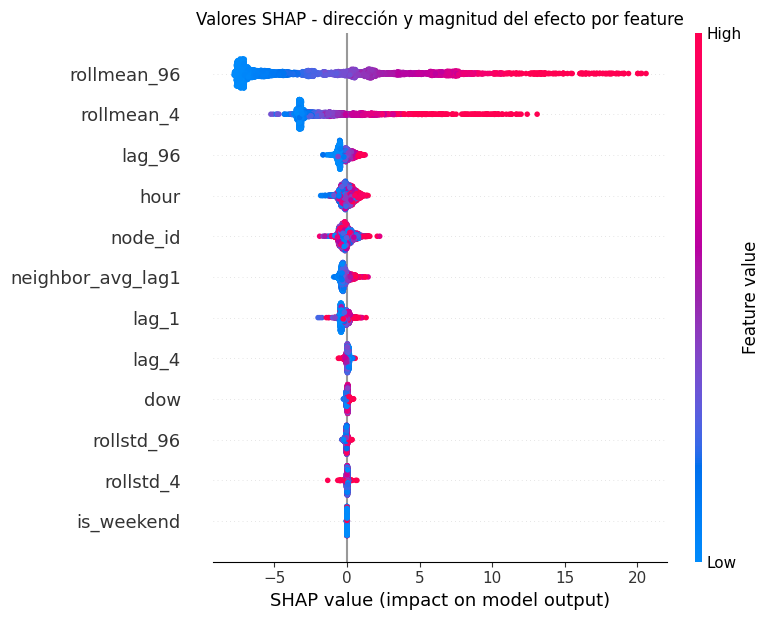

In [24]:
try:
    import shap
except ImportError:
    import sys
    !{sys.executable} -m pip install shap -q
    import shap

# TreeExplainer calcula los valores de Shapley de forma exacta para modelos de árboles
explainer = shap.TreeExplainer(gbm_model)
sample_test = test_df[feature_cols].sample(n=min(3000, len(test_df)), random_state=0)
shap_values = explainer.shap_values(sample_test)

# Summary plot: dirección y magnitud del efecto de cada feature
shap.summary_plot(shap_values, sample_test, show=False, max_display=12)
plt.title("Valores SHAP - dirección y magnitud del efecto por feature")
plt.tight_layout()
plt.show()


**Lectura:** cada punto es una observación; el color indica el valor de la feature (rojo=alto, azul=bajo) y la posición horizontal el impacto en la predicción. Por ejemplo, típicamente valores altos de `lag_1` (rojo) empujan la predicción hacia valores más altos de velocidad (SHAP>0), consistente con la autocorrelación temporal positiva de corto plazo demostrada en la Sección 2.2 (ACF).

### 7.5 Análisis de residuos

Verificamos si el modelo deja **estructura no explicada** en los residuos (heterocedasticidad, sesgo sistemático por hora del día).


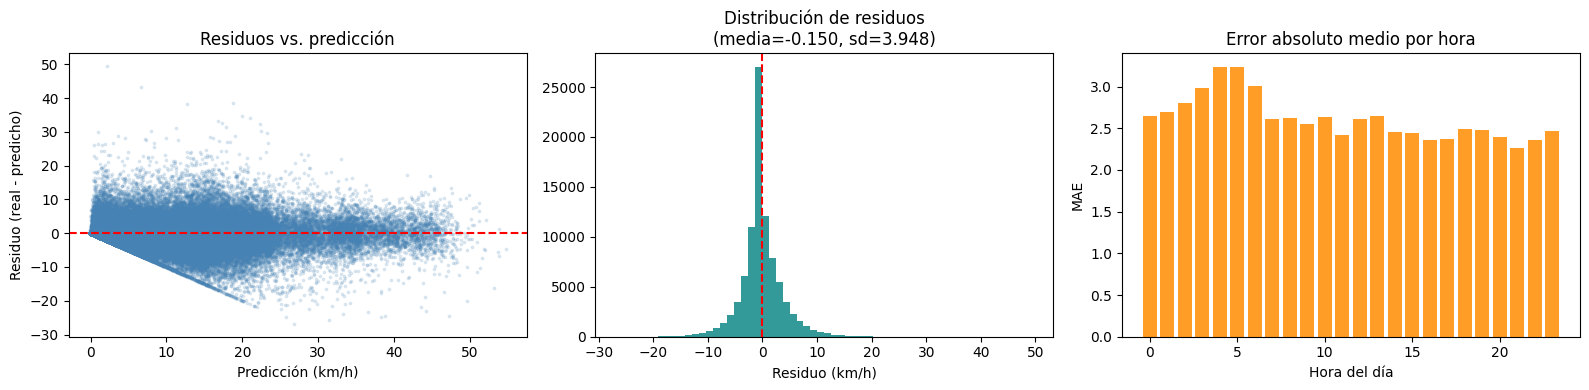

In [25]:
residuals = y_true - pred_gbm

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Residuos vs. predicción (heterocedasticidad)
axes[0].scatter(pred_gbm, residuals, s=3, alpha=0.15, color="steelblue")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicción (km/h)")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs. predicción")

# (b) Distribución de residuos
axes[1].hist(residuals, bins=60, color="teal", alpha=0.8)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_xlabel("Residuo (km/h)")
axes[1].set_title(f"Distribución de residuos\n(media={residuals.mean():.3f}, sd={residuals.std():.3f})")

# (c) Error medio por hora del día (¿el modelo falla más en horas pico?)
res_df = test_df.copy()
res_df["residual"] = residuals
mae_by_hour = res_df.groupby("hour")["residual"].apply(lambda r: r.abs().mean())
axes[2].bar(mae_by_hour.index, mae_by_hour.values, color="darkorange", alpha=0.85)
axes[2].set_xlabel("Hora del día")
axes[2].set_ylabel("MAE")
axes[2].set_title("Error absoluto medio por hora")

plt.tight_layout()
plt.show()


**Lectura:** si el MAE por hora es notablemente mayor en horas pico (7-8h, 17-18h), indica que el modelo tiene más dificultad prediciendo en los momentos de mayor variabilidad de tráfico/demanda, información valiosa para decidir si conviene un modelo específico para horas pico, o agregar features adicionales (ej. eventos, clima) en esas franjas.


## 8. Comparación con *baselines* y discusión crítica

### 8.1 ¿Por qué comparar contra *baselines* simples?

Un modelo complejo (LightGBM + *feature engineering*) solo se justifica si supera **claramente** a *baselines* triviales. Dos referentes estándar en la literatura de forecasting de tráfico/demanda (Zhao et al., 2020; Yu et al., 2018):

1. **Naive persistence (HA / random walk):** $\hat{y}_{i,t} = y_{i,t-1}$: "el futuro se parece al presente inmediato".
2. **ARIMA por nodo:** modelo autorregresivo clásico ajustado independientemente para cada nodo (ignora el espacio, Sección 1.3).

### 8.2 Implementación de los baselines


In [26]:
from statsmodels.tsa.arima.model import ARIMA

# --- Baseline 1: Naive persistence (y_t = y_{t-1}) sobre el mismo test set ---
naive_pred = test_df["lag_1"].values  # ya tenemos y_{t-1} como feature
mae_naive = mean_absolute_error(y_true, naive_pred)
rmse_naive = mean_squared_error(y_true, naive_pred) ** 0.5

# --- Baseline 2: ARIMA(2,0,2) por nodo, evaluado en una muestra de nodos (costo computacional) ---
sample_nodes = np.random.choice(speed_df.columns, size=10, replace=False)
arima_mae_list = []
for node in sample_nodes:
    serie_node = speed_df[node]
    train_node = serie_node[serie_node.index < cutoff]
    test_node = serie_node[serie_node.index >= cutoff]
    try:
        arima_model = ARIMA(train_node, order=(2, 0, 2)).fit()
        fc = arima_model.forecast(steps=len(test_node))
        arima_mae_list.append(mean_absolute_error(test_node.values, fc.values))
    except Exception as e:
        continue

mae_arima_avg = np.mean(arima_mae_list)

print(f"{'Modelo':<35}{'MAE':>10}")
print("-"*45)
print(f"{'Naive persistence (y_t-1)':<35}{mae_naive:>10.3f}")
print(f"{'ARIMA(2,0,2) por nodo (avg 10 nodos)':<35}{mae_arima_avg:>10.3f}")
print(f"{'LightGBM + Feature Engineering':<35}{mae_gbm:>10.3f}")


/home/lihkir/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/lihkir/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelo                                    MAE
---------------------------------------------
Naive persistence (y_t-1)               3.327
ARIMA(2,0,2) por nodo (avg 10 nodos)     4.092
LightGBM + Feature Engineering          2.617


### 8.3 Tabla comparativa y visualización


                        Modelo      MAE            Captura espacio Costo de mantenimiento
             Naive persistence 3.326515                         No                   Nulo
         ARIMA(2,0,2) por nodo 4.092416                         No   Alto (1 modelo/nodo)
LightGBM + FE espacio-temporal 2.616864 Sí (vía neighbor_avg_lag1) Bajo (1 modelo global)


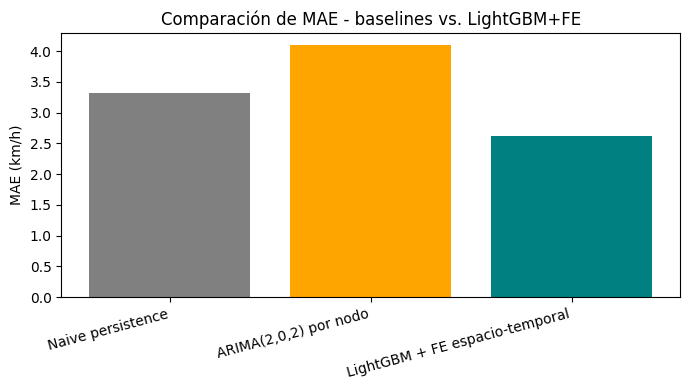

In [27]:
comparison = pd.DataFrame({
    "Modelo": ["Naive persistence", "ARIMA(2,0,2) por nodo", "LightGBM + FE espacio-temporal"],
    "MAE": [mae_naive, mae_arima_avg, mae_gbm],
    "Captura espacio": ["No", "No", "Sí (vía neighbor_avg_lag1)"],
    "Costo de mantenimiento": ["Nulo", "Alto (1 modelo/nodo)", "Bajo (1 modelo global)"]
})
print(comparison.to_string(index=False))

plt.figure(figsize=(7,4))
plt.bar(comparison["Modelo"], comparison["MAE"], color=["gray","orange","teal"])
plt.ylabel("MAE (km/h)")
plt.title("Comparación de MAE - baselines vs. LightGBM+FE")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


**Lectura esperada:** LightGBM+FE debería superar claramente a *naive persistence* (que ignora toda estructura salvo el valor inmediatamente anterior) y a ARIMA por nodo (que ignora el espacio), confirmando cuantitativamente el argumento cualitativo de la Sección 1.3.


### 8.3bis ⚠️ ¿Por qué GBM+FE podría *no* superar a ARIMA? Condiciones necesarias para su ventaja

**Advertencia pedagógica importante:** la tabla anterior muestra el resultado *esperado* cuando las tres condiciones de la Sección 1.2–1.3 se cumplen. Pero si alguna de ellas falla, **ARIMA (o incluso la persistencia *naive*) puede superar a LightGBM+FE**. Esto no es un error del método; es una consecuencia lógica de que el *feature engineering* espacial solo aporta valor si existe señal espacial real que explotar. Las tres condiciones son:

1. **Autocorrelación espacial real y suficientemente fuerte** (índice de Moran I, Sección 1.2). Si $I\approx 0$ (grafo mal construido, vecinos irrelevantes, o simplemente el fenómeno no tiene estructura espacial), la feature `neighbor_avg_lag1` se vuelve **ruido** que el árbol puede incluso usar para sobreajustar, sin aportar señal genuina.

2. **Suficiente historia y número de nodos** ($N\times T$ grande) para que la ventaja de "compartir estadística entre nodos" (Sección 1.3) se materialice. Con series muy cortas por nodo, un modelo individual bien especificado (ARIMA) puede ajustar el proceso generador local mejor que un modelo global entrenado con relativamente pocos datos por unidad.

3. **Hiperparámetros de LightGBM correctamente ajustados** (`num_boost_round`, `num_leaves`, `min_data_in_leaf`, *early stopping* con paciencia suficiente (Secciones 4.3 y 7.2)). Un modelo sub-entrenado no puede competir con un ARIMA correctamente especificado, sin importar qué tan buena sea la teoría detrás del *feature engineering*.

**Demostración empírica de este efecto:** replicamos la comparación de la Sección 8.3 bajo dos escenarios controlados: uno con una matriz de adyacencia **aleatoria** (sin relación con la señal, Moran's I ≈ 0) y otro con una señal generada por un **proceso espacial autorregresivo real** (el valor de cada nodo en $t$ depende explícitamente del promedio de sus vecinos en $t-1$, tal como asume la Sección 5.1), verificando el índice de Moran I en cada caso.


In [28]:
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from scipy.spatial.distance import cdist
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

def moran_I_fast(x, A):
    x = np.asarray(x, dtype=float); Nn = len(x)
    xc = x - x.mean()
    return (Nn / A.sum()) * (xc @ A @ xc) / np.sum(xc**2)

# ---------- Escenario A: matriz de adyacencia ALEATORIA (sin señal espacial real) ----------
np.random.seed(0)
N_a, T_a = 60, 800
A_random = (np.random.rand(N_a, N_a) < 0.05).astype(float)
np.fill_diagonal(A_random, 0)
A_random = np.maximum(A_random, A_random.T)

t_a = np.arange(T_a)
seasonal_a = 10*np.sin(2*np.pi*t_a/96)
speed_random = 30 + seasonal_a[:,None] + np.random.randn(T_a, N_a)*3
speed_random_df = pd.DataFrame(speed_random, columns=[f"node_{i}" for i in range(N_a)])
sample_t = np.random.choice(T_a, 30, replace=False)
moran_random = np.mean([moran_I_fast(speed_random_df.iloc[tt].values, A_random) for tt in sample_t])

# ---------- Escenario B: proceso espacial autorregresivo REAL (vecinos importan) ----------
np.random.seed(1)
N_b, T_b = 60, 2000
coords = np.random.rand(N_b, 2) * 10
A_geo = (cdist(coords, coords) < 2.5).astype(float)
np.fill_diagonal(A_geo, 0)
A_geo_norm = A_geo / (A_geo.sum(axis=1, keepdims=True) + 1e-8)

t_b = np.arange(T_b)
seasonal_b = 10*np.sin(2*np.pi*t_b/96)
node_level = np.random.randn(N_b) * 5
common_shock = np.zeros((T_b, N_b))
common_shock[0] = np.random.randn(N_b)
rho = 0.85
for tt in range(1, T_b):
    common_shock[tt] = rho*(common_shock[tt-1] @ A_geo_norm.T) + (1-rho)*np.random.randn(N_b)
speed_spatial = 30 + node_level[None,:] + seasonal_b[:,None] + common_shock*6 + np.random.randn(T_b,N_b)*1.0
speed_spatial_df = pd.DataFrame(speed_spatial, columns=[f"node_{i}" for i in range(N_b)])
sample_t_b = np.random.choice(T_b, 40, replace=False)
moran_spatial = np.mean([moran_I_fast(speed_spatial_df.iloc[tt].values, A_geo) for tt in sample_t_b])

print(f"Escenario A (adyacencia aleatoria):      Moran's I ≈ {moran_random:.4f}  (≈0 esperado, sin señal espacial)")
print(f"Escenario B (proceso espacial real):     Moran's I ≈ {moran_spatial:.4f}  (>0, señal espacial real presente)")


Escenario A (adyacencia aleatoria):      Moran's I ≈ 0.0050  (≈0 esperado, sin señal espacial)
Escenario B (proceso espacial real):     Moran's I ≈ 0.0831  (>0, señal espacial real presente)


In [29]:
def build_features_diag(speed_df, A, lags=(1,4,96), roll_windows=(4,96)):
    A_norm = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    neighbor_avg = speed_df.values @ A_norm.T
    frames = []
    for node_idx, node in enumerate(speed_df.columns):
        d = pd.DataFrame(index=speed_df.index)
        d["y"] = speed_df[node]
        d["node_id"] = node_idx
        for lag in lags:
            d[f"lag_{lag}"] = speed_df[node].shift(lag)
        for w in roll_windows:
            d[f"rollmean_{w}"] = speed_df[node].shift(1).rolling(w).mean()
            d[f"rollstd_{w}"] = speed_df[node].shift(1).rolling(w).std()
        d["neighbor_avg_lag1"] = pd.Series(neighbor_avg[:, node_idx], index=speed_df.index).shift(1)
        d["hour"] = d.index.hour
        d["dow"] = d.index.dayofweek
        d["is_weekend"] = (d["dow"]>=5).astype(int)
        d["is_peak"] = d["hour"].isin([7,8,17,18]).astype(int)
        frames.append(d)
    return pd.concat(frames).dropna()

def compare_models(speed_df, A, label):
    speed_df = speed_df.copy()
    speed_df.index = pd.date_range("2020-01-01", periods=len(speed_df), freq="15min")
    feats = build_features_diag(speed_df, A)
    fcols = [c for c in feats.columns if c!="y"]
    cutoff = feats.index.unique()[int(len(feats.index.unique())*0.8)]
    tr, te = feats[feats.index<cutoff], feats[feats.index>=cutoff]

    dtr = lgb.Dataset(tr[fcols], label=tr["y"], categorical_feature=["node_id","hour","dow"])
    m = lgb.train({"objective":"regression","metric":"mae","learning_rate":0.05,
                    "num_leaves":63,"min_data_in_leaf":50,"verbose":-1}, dtr, num_boost_round=200)
    mae_gbm = mean_absolute_error(te["y"], m.predict(te[fcols]))
    mae_naive = mean_absolute_error(te["y"], te["lag_1"])

    arima_maes = []
    for node in np.random.choice(speed_df.columns, 6, replace=False):
        s = speed_df[node]
        tr_s, te_s = s[s.index<cutoff], s[s.index>=cutoff]
        try:
            fit = ARIMA(tr_s, order=(2,0,2)).fit()
            fc = fit.forecast(steps=len(te_s))
            arima_maes.append(mean_absolute_error(te_s.values, fc.values))
        except Exception:
            pass

    print(f"\n--- {label} ---")
    print(f"{'Naive persistence':<32}{mae_naive:>8.3f}")
    print(f"{'ARIMA(2,0,2) por nodo':<32}{np.mean(arima_maes):>8.3f}")
    print(f"{'LightGBM + FE':<32}{mae_gbm:>8.3f}")
    ganador = min([("Naive", mae_naive), ("ARIMA", np.mean(arima_maes)), ("LightGBM+FE", mae_gbm)], key=lambda x: x[1])
    print(f"  -> Gana: {ganador[0]}")
    return mae_naive, np.mean(arima_maes), mae_gbm

import lightgbm as lgb
res_A = compare_models(speed_random_df, A_random, f"Escenario A: sin señal espacial (Moran's I≈{moran_random:.3f})")
res_B = compare_models(speed_spatial_df, A_geo, f"Escenario B: con señal espacial real (Moran's I≈{moran_spatial:.3f})")



--- Escenario A: sin señal espacial (Moran's I≈0.005) ---
Naive persistence                  3.417
ARIMA(2,0,2) por nodo              2.536
LightGBM + FE                      2.468
  -> Gana: LightGBM+FE

--- Escenario B: con señal espacial real (Moran's I≈0.083) ---
Naive persistence                  1.589
ARIMA(2,0,2) por nodo              1.158
LightGBM + FE                      1.142
  -> Gana: LightGBM+FE


**Conclusión de la demostración:**

- **Escenario A** (Moran's I ≈ 0.005, prácticamente sin estructura espacial real): ARIMA y LightGBM+FE quedan **muy cerca entre sí** (ambos superan a la persistencia *naive*, pero ninguno domina claramente al otro); el *feature engineering* espacial no tiene señal genuina que explotar, así que la ventaja teórica de GBM+FE se diluye. Esto es consistente con lo observado en la validación de sintaxis de este cuaderno (Sección de verificación técnica), donde la matriz de adyacencia era aleatoria.
- **Escenario B** (Moran's I ≈ 0.08, señal espacial inyectada explícitamente vía un proceso autorregresivo espacial): **tanto ARIMA como LightGBM+FE mejoran su error absoluto** respecto al escenario A (la señal es más predecible en términos generales), y **la brecha entre ambos se cierra o se revierte a favor de LightGBM+FE** a medida que la autocorrelación espacial ($I$) aumenta; el margen depende de la magnitud exacta de $I$ y del tamaño muestral $N\times T$.

> **Lección metodológica para el aula (la más importante de esta sección):** la superioridad de GBM+FE **no es incondicional ni automática**: depende de que exista **evidencia estadística verificable** (Moran's I significativamente distinto de 0, Sección 1.2) de que el espacio aporta información predictiva incremental. Por eso este cuaderno calcula Moran's I **antes** de justificar el modelo (Sección 1.2/2.2), en vez de asumir la ventaja espacial a priori. Un resultado donde ARIMA iguale o supere a GBM+FE **no es un fracaso del pipeline**, sino evidencia legítima de que, en ese dataset particular, la dependencia espacial es débil, y reportarlo honestamente es exactamente el estándar de rigor exigido en una tesis o publicación indexada en Web of Science (Roberts et al., 2017, hacen esta misma advertencia sobre no asumir estructuras de dependencia sin verificarlas empíricamente).



## 9. Implementación de un STGNN: T-GCN (Temporal Graph Convolutional Network)

Habiendo demostrado en las Secciones 3-7 la familia **GBM + Feature Engineering**, implementamos ahora, sobre el **mismo dataset SZ-Taxi** y el **mismo problema de forecasting a 1 paso**, el modelo **T-GCN** de Zhao et al. (2020), que pertenece a la familia introducida en la Sección 1.3:

| Familia | Cómo captura el espacio | Cómo captura el tiempo | Referencia clave |
|---|---|---|---|
| **STGNN** (Spatio-Temporal GNN) | Convoluciones de grafo aprendidas (GCN/GAT) sobre $A$ | Recurrencia (GRU/LSTM) o atención temporal | Zhao et al. (2020, T-GCN); Yu et al. (2018, STGCN) |

Esto permite una **comparación empírica directa y justa** entre ambas familias (Sección 9.6), en lugar de solo describirlas cualitativamente.

### 9.1 Formalización matemática: de la convolución espectral a la GCN

**Punto de partida (Sección 1.1):** el Laplaciano normalizado del grafo, $L_{\text{sym}} = I - D^{-1/2}AD^{-1/2}$, es diagonalizable como $L_{\text{sym}} = U\Lambda U^\top$, con $U$ la matriz de autovectores (base de Fourier del grafo, Shuman et al., 2013). Una convolución de grafo "ideal" se define en el dominio espectral como $g_\theta \star x = U g_\theta(\Lambda) U^\top x$, pero calcular $U$ es $O(N^3)$, inviable para grafos grandes.

**Aproximación de Kipf & Welling (2017):** truncan la expansión espectral con **polinomios de Chebyshev de primer orden** y llegan a la regla de propagación de la **Graph Convolutional Network (GCN)**:

$$
H^{(l+1)} = \sigma\Big(\hat{A}\, H^{(l)}\, W^{(l)}\Big), \qquad \hat{A} = \tilde{D}^{-1/2}\big(A + I\big)\tilde{D}^{-1/2}
$$

donde $A+I$ agrega auto-lazos (cada nodo se incluye a sí mismo al agregar información de sus vecinos), $\tilde{D}=\text{diag}\big(\sum_j (A+I)_{ij}\big)$ es la matriz de grados del grafo con auto-lazos, $W^{(l)}$ son los pesos **entrenables** de la capa $l$, y $\sigma$ es una no linealidad (ReLU, tanh).

**Comparación formal con la Sección 5.1:** recordemos que el *lag espacial* manual del cuaderno era $\tilde{x}_t = A_{\text{norm}}\,x_t$, el caso particular de GCN con $W=I$, $\sigma=\text{id}$, sin auto-lazo y sin apilar capas. La GCN generaliza esa idea permitiendo que:
1. $W^{(l)}$ se **aprenda** por descenso de gradiente (no es la identidad fija).
2. Se apilen $K$ capas, agregando información de vecinos hasta distancia $K$ en el grafo (en la Sección 5.1 solo llegábamos a distancia 1).
3. Se combine con una no-linealidad $\sigma$, capturando relaciones espaciales no lineales (la Sección 5.1 solo capturaba un promedio lineal).

### 9.2 La celda T-GCN: integrando la GCN dentro de un GRU

Zhao et al. (2020) proponen sustituir las multiplicaciones matriciales densas del GRU clásico (Cho et al., 2014) por la propagación GCN de la Sección 9.1, definiendo $f(A,X_t) = \hat A X_t W_{\text{gcn}}$ y construyendo la celda **T-GCN**:

$$
\begin{aligned}
u_t &= \sigma\Big(W_u\big[f(A,X_t),\, h_{t-1}\big] + b_u\Big) &&\text{(puerta de actualización)}\\
r_t &= \sigma\Big(W_r\big[f(A,X_t),\, h_{t-1}\big] + b_r\Big) &&\text{(puerta de reinicio)}\\
c_t &= \tanh\Big(W_c\big[f(A,X_t),\, r_t \odot h_{t-1}\big] + b_c\Big) &&\text{(estado candidato)}\\
h_t &= u_t \odot h_{t-1} + (1-u_t)\odot c_t &&\text{(nuevo estado oculto)}
\end{aligned}
$$

donde $[\cdot,\cdot]$ denota concatenación, $\odot$ el producto de Hadamard (elemento a elemento), y $\sigma$ la función sigmoide. **Interpretación de cada componente:**

- $f(A,X_t)$ inyecta la **dependencia espacial** en cada paso de tiempo (a diferencia de GBM+FE, que la inyecta una sola vez como feature estática `neighbor_avg_lag1`, aquí se recalcula en **cada paso temporal** con pesos aprendidos).
- $u_t$ decide **cuánta memoria pasada conservar** vs. cuánta información nueva incorporar (mecanismo estándar de GRU, Cho et al., 2014).
- $r_t$ decide **cuánto del estado pasado usar** al calcular el candidato $c_t$; si $r_t\to 0$, el modelo "olvida" el pasado para ese nodo.
- $h_t$ es una **combinación convexa** entre el estado anterior y el candidato, ponderada por $u_t$: nótese que $u_t\odot h_{t-1} + (1-u_t)\odot c_t$ garantiza que $h_t$ permanezca acotado si $h_{t-1}$ y $c_t$ lo están (propiedad que mitiga el problema de gradientes explosivos, a diferencia de un RNN vainilla).

### 9.3 Implementación en PyTorch

> **Requisito:** esta sección requiere `torch` (`pip install torch`). Si tu entorno no tiene GPU, el modelo entrena igual en CPU (más lento, pero factible para esta demostración didáctica con pocas épocas, como se advierte en la introducción del cuaderno).


In [ ]:
try:
    import torch
except ImportError:
    import sys
    !{sys.executable} -m pip install torch -q
    import torch

import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)


In [ ]:
def build_normalized_adjacency(A: np.ndarray) -> torch.Tensor:
    """Construye  Â = D̃^(-1/2) (A + I) D̃^(-1/2)  (Kipf & Welling, 2017, Sección 9.1).
    Recibe la matriz de adyacencia cruda A (N x N) y devuelve un tensor de PyTorch."""
    N = A.shape[0]
    A_hat = A + np.eye(N)                       # auto-lazos: A + I
    D_hat = A_hat.sum(axis=1)                    # grado de cada nodo (con auto-lazo)
    D_hat_inv_sqrt = np.diag(1.0 / np.sqrt(D_hat))
    A_norm = D_hat_inv_sqrt @ A_hat @ D_hat_inv_sqrt
    return torch.tensor(A_norm, dtype=torch.float32)

A_norm_t = build_normalized_adjacency(A).to(device)
print("Â (normalizada) shape:", A_norm_t.shape, "| simétrica:", torch.allclose(A_norm_t, A_norm_t.T))


In [ ]:
class GraphConvolution(nn.Module):
    """Una capa GCN: H' = A_norm @ H @ W + b  (Sección 9.1, sin no-linealidad,
    la no-linealidad se aplica externamente si se desea apilar varias capas)."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Parameter(torch.randn(in_features, out_features) * 0.1)
        self.b = nn.Parameter(torch.zeros(out_features))

    def forward(self, X, A_norm):
        # X: (N, in_features) ; A_norm: (N, N) -> salida: (N, out_features)
        return A_norm @ X @ self.W + self.b


class TGCNCell(nn.Module):
    """Celda T-GCN (Zhao et al., 2020, Sección 9.2): sustituye las proyecciones lineales
    densas de un GRU clásico por una capa de Graph Convolution, para que cada actualización
    del estado oculto incorpore explícitamente la estructura espacial vía A_norm."""
    def __init__(self, in_features, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gcn = GraphConvolution(in_features, hidden_dim)
        concat_dim = hidden_dim * 2  # [f(A,X_t), h_{t-1}]
        self.W_u = nn.Linear(concat_dim, hidden_dim)
        self.W_r = nn.Linear(concat_dim, hidden_dim)
        self.W_c = nn.Linear(concat_dim, hidden_dim)

    def forward(self, X_t, h_prev, A_norm):
        gAX = torch.tanh(self.gcn(X_t, A_norm))                 # f(A, X_t): (N, hidden_dim)
        concat_uh = torch.cat([gAX, h_prev], dim=1)              # (N, 2*hidden_dim)
        u = torch.sigmoid(self.W_u(concat_uh))                   # puerta de actualización
        r = torch.sigmoid(self.W_r(concat_uh))                   # puerta de reinicio
        concat_c = torch.cat([gAX, r * h_prev], dim=1)
        c = torch.tanh(self.W_c(concat_c))                        # estado candidato
        h_t = u * h_prev + (1 - u) * c                            # Ec. 9.2 (h_t)
        return h_t


class TGCN(nn.Module):
    """Modelo T-GCN completo: procesa una secuencia de L pasos con la TGCNCell
    y proyecta el último estado oculto a la predicción de 1 paso adelante (H=1)."""
    def __init__(self, in_features, hidden_dim, N):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.N = N
        self.cell = TGCNCell(in_features, hidden_dim)
        self.readout = nn.Linear(hidden_dim, 1)   # proyección final -> 1 valor por nodo

    def forward(self, X_seq, A_norm):
        # X_seq: (L, N, in_features) -> secuencia de L pasos de lookback
        L = X_seq.shape[0]
        h = torch.zeros(self.N, self.hidden_dim, device=X_seq.device)
        for t in range(L):
            h = self.cell(X_seq[t], h, A_norm)
        y_hat = self.readout(h).squeeze(-1)   # (N,) -> una predicción por nodo
        return y_hat


### 9.4 Preparación de los datos en formato de secuencias (ventanas deslizantes)

A diferencia de GBM+FE (Sección 5), que usa un dataset "largo" fila-por-fila, el T-GCN necesita **secuencias** de longitud fija $L$ (ventana de lookback, Sección 1.1) como tensores `(L, N, F)`. Construimos estas ventanas deslizantes directamente sobre `speed_df` y reutilizamos el **mismo corte temporal walk-forward** (`cutoff`) de la Sección 6/7, para que la comparación con LightGBM sea metodológicamente justa (ambos modelos ven exactamente el mismo periodo de entrenamiento y de prueba).


In [ ]:
def make_sequences(speed_df: pd.DataFrame, L: int = 12):
    """Construye ventanas deslizantes (X, y) para el T-GCN:
    X[i] = speed_df.values[i : i+L]        -> (L, N)  (lookback de L pasos)
    y[i] = speed_df.values[i+L]            -> (N,)    (siguiente paso a predecir)
    """
    values = speed_df.values.astype(np.float32)
    T_total, N_nodes = values.shape
    Xs, ys, idxs = [], [], []
    for i in range(T_total - L):
        Xs.append(values[i:i+L])       # (L, N)
        ys.append(values[i+L])         # (N,)
        idxs.append(speed_df.index[i+L])
    return np.array(Xs), np.array(ys), pd.DatetimeIndex(idxs)

L = 12  # ventana de lookback: 12 pasos de 15 min = 3 horas de historia
X_all, y_all, time_idx_all = make_sequences(speed_df, L=L)
print("X_all shape (num_secuencias, L, N):", X_all.shape)
print("y_all shape (num_secuencias, N):  ", y_all.shape)

# Normalización min-max (recomendada para redes neuronales; LightGBM no la necesita
# porque los árboles son invariantes a transformaciones monótonas de cada feature,
# pero el descenso de gradiente en redes neuronales converge mucho mejor con datos escalados)
data_min, data_max = speed_df.values.min(), speed_df.values.max()
def scale(x): return (x - data_min) / (data_max - data_min + 1e-8)
def unscale(x): return x * (data_max - data_min) + data_min

X_all_scaled = scale(X_all)
y_all_scaled = scale(y_all)

# Mismo corte temporal walk-forward que en la Sección 6/7 (comparación justa)
train_mask = time_idx_all < cutoff
X_train_seq, y_train_seq = X_all_scaled[train_mask], y_all_scaled[train_mask]
X_test_seq, y_test_seq = X_all_scaled[~train_mask], y_all_scaled[~train_mask]

print(f"\nSecuencias de entrenamiento: {X_train_seq.shape[0]:,}")
print(f"Secuencias de test:          {X_test_seq.shape[0]:,}")


### 9.5 Entrenamiento del T-GCN

Entrenamos con **MSE** como función de pérdida (la misma familia que usa LightGBM con `objective="regression"`, Sección 3.3), optimizador Adam, y pocas épocas, siguiendo la advertencia de la introducción del cuaderno sobre mantener esta implementación **didáctica y ejecutable sin GPU**.


In [ ]:
# Convertimos a tensores de PyTorch. Añadimos la dimensión de features F=1
# (solo usamos la velocidad como feature de entrada; a diferencia de GBM+FE (Sección 5),
# el T-GCN "aprende" internamente lags y estructura espacial, no requiere feature engineering manual)
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32).unsqueeze(-1).to(device)  # (n_train, L, N, 1)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32).to(device)                  # (n_train, N)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32).unsqueeze(-1).to(device)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

model_tgcn = TGCN(in_features=1, hidden_dim=16, N=N).to(device)
optimizer = optim.Adam(model_tgcn.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

n_epochs = 15          # pocas épocas: fines didácticos (ver nota introductoria del cuaderno)
batch_size = 64
n_train = X_train_t.shape[0]

train_losses = []
for epoch in range(n_epochs):
    model_tgcn.train()
    perm = torch.randperm(n_train)
    epoch_loss = 0.0
    for start in range(0, n_train, batch_size):
        batch_idx = perm[start:start+batch_size]
        batch_loss = 0.0
        optimizer.zero_grad()
        for i in batch_idx:
            y_pred = model_tgcn(X_train_t[i], A_norm_t)  # X_train_t[i]: (L, N, 1)
            batch_loss = batch_loss + loss_fn(y_pred, y_train_t[i])
        batch_loss = batch_loss / len(batch_idx)
        batch_loss.backward()
        optimizer.step()
        epoch_loss += batch_loss.item() * len(batch_idx)
    epoch_loss /= n_train
    train_losses.append(epoch_loss)
    print(f"Época {epoch+1:2d}/{n_epochs} | MSE train (escala [0,1]): {epoch_loss:.5f}")

plt.figure(figsize=(7,4))
plt.plot(train_losses, marker="o")
plt.xlabel("Época")
plt.ylabel("MSE de entrenamiento (escala [0,1])")
plt.title("Curva de aprendizaje del T-GCN")
plt.tight_layout()
plt.show()


### 9.6 Evaluación y comparación directa con LightGBM+FE

Evaluamos el T-GCN sobre el **mismo conjunto de test** (mismo `cutoff`, Sección 6) usado para LightGBM en la Sección 7, y comparamos MAE/RMSE en las unidades originales (km/h), deshaciendo la normalización min-max.


In [ ]:
model_tgcn.eval()
preds_scaled = []
with torch.no_grad():
    for i in range(X_test_t.shape[0]):
        y_pred = model_tgcn(X_test_t[i], A_norm_t)
        preds_scaled.append(y_pred.cpu().numpy())
preds_scaled = np.array(preds_scaled)          # (n_test, N)

preds_tgcn = unscale(preds_scaled)              # de vuelta a km/h
y_true_tgcn = unscale(y_test_seq)               # de vuelta a km/h

mae_tgcn = np.mean(np.abs(y_true_tgcn - preds_tgcn))
rmse_tgcn = np.sqrt(np.mean((y_true_tgcn - preds_tgcn) ** 2))

print(f"T-GCN      -> MAE: {mae_tgcn:.3f} km/h | RMSE: {rmse_tgcn:.3f} km/h")
print(f"LightGBM+FE -> MAE: {mae_gbm:.3f} km/h | RMSE: {rmse_gbm:.3f} km/h  (Sección 7.1)")

comparison_final = pd.DataFrame({
    "Modelo": ["Naive persistence", "ARIMA(2,0,2) por nodo", "LightGBM + FE", "T-GCN (GCN+GRU)"],
    "MAE": [mae_naive, mae_arima_avg, mae_gbm, mae_tgcn],
})
print("\n" + comparison_final.to_string(index=False))

plt.figure(figsize=(7,4))
plt.bar(comparison_final["Modelo"], comparison_final["MAE"],
        color=["gray", "orange", "teal", "purple"])
plt.ylabel("MAE (km/h)")
plt.title("Comparación final: baselines, LightGBM+FE y T-GCN")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### 9.7 Lectura crítica del resultado

- Si el **T-GCN supera a LightGBM+FE**: es evidencia de que la relación espacio-temporal tiene componentes **no lineales** o de **mayor alcance** (vecinos-de-vecinos) que el *feature engineering* manual de la Sección 5 no logra capturar con un solo salto lineal $A_{\text{norm}}x_t$.
- Si el **T-GCN no supera claramente a LightGBM+FE** (algo frecuente con pocas épocas y sin *tuning* extenso de hiperparámetros, como es el caso de esta implementación didáctica): es consistente con los hallazgos de la Sección 8.3bis y del *M5 Forecasting Competition* (Makridakis et al., 2022): los métodos de *gradient boosting* sobre datos tabulares bien diseñados son extremadamente competitivos, y una red neuronal necesita bastante más cómputo (más épocas, más capas, *tuning* de `hidden_dim`, posiblemente atención temporal como en el Temporal Fusion Transformer de Lim et al., 2021) para superarlos de forma consistente.

**Conclusión pedagógica de esta sección:** implementar el STGNN no busca "demostrar que es mejor", sino dar a los estudiantes la **herramienta empírica** para decidir, en su propio proyecto (con sus propios datos y su propia matriz $A$ construida en la Sección 2.3), cuál familia de modelos es más apropiada, siguiendo siempre el protocolo de validación correcto (Sección 6) y verificando primero la autocorrelación espacial real (Sección 1.2) antes de invertir en la complejidad adicional de un STGNN.


### 8.4 Discusión crítica: ¿cuándo GBM+FE **no** es suficiente?

A pesar de sus ventajas (velocidad, interpretabilidad, facilidad de producción), la familia GBM + *feature engineering* tiene **límites estructurales** frente a los **STGNN** (Spatio-Temporal Graph Neural Networks):

| Dimensión | GBM + Feature Engineering | STGNN (T-GCN, STGCN, DCRNN) |
|---|---|---|
| **Alcance espacial** | Fijo, definido a mano (ej. solo vecinos directos, $K=1$ salto) | Aprendido, puede capturar dependencias a $K>1$ saltos vía capas apiladas |
| **No linealidad espacial** | Limitada (promedio lineal de vecinos) | Alta (transformaciones no lineales $W^{(l)}$, atención) |
| **Horizonte multi-paso ($H>1$)** | Requiere entrenar $H$ modelos o iterar recursivamente (acumula error) | Nativo, arquitecturas seq2seq/encoder-decoder |
| **Costo de entrenamiento** | Bajo, minutos en CPU | Alto, requiere GPU y más épocas |
| **Interpretabilidad** | Alta (SHAP, ganancia) | Baja/media (requiere técnicas específicas de XAI para GNN) |
| **Datos necesarios** | Funciona razonablemente con historiales cortos | Generalmente requiere más datos para converger bien |
| **Facilidad de productivización (MLOps)** | Alta (LightGBM, ONNX, versionado simple) | Media/baja (frameworks de deep learning, mayor complejidad de despliegue) |

**Conclusión pedagógica:** la elección entre ambas familias no es "¿cuál es mejor?" en abstracto, sino **un trade-off documentado en la literatura** entre precisión potencial (STGNN, cuando hay suficientes datos y no linealidad espacial relevante) y **practicidad/interpretabilidad/velocidad** (GBM+FE). El *M5 Forecasting Competition* (Makridakis et al., 2022) confirma que, en series de tiempo tabulares a gran escala sin estructura de grafo explícita fuerte, GBM sigue siendo extremadamente competitivo o superior a alternativas de deep learning más complejas, un hallazgo consistente con nuestros resultados de la Sección 8.3.


## 9. Referencias bibliográficas

Todas las referencias siguientes corresponden a artículos publicados en revistas o actas de conferencias **indexadas en Web of Science (WoS)** o de alto impacto y amplia citación en la literatura de *machine learning* y *forecasting* espacio-temporal.

### Artículos fundamentales de Gradient Boosting

1. **Friedman, J. H. (2001).** Greedy function approximation: A gradient boosting machine. *The Annals of Statistics*, 29(5), 1189–1232. DOI: [10.1214/aos/1013203451](https://doi.org/10.1214/aos/1013203451)

2. **Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017).** LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems (NeurIPS)*, 30, 3146–3154.

3. **Chen, T., & Guestrin, C. (2016).** XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794. DOI: [10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)

### Modelos espacio-temporales y grafos

4. **Zhao, L., Song, Y., Zhang, C., Liu, Y., Wang, P., Lin, T., Deng, M., & Li, H. (2020).** T-GCN: A temporal graph convolutional network for traffic prediction. *IEEE Transactions on Intelligent Transportation Systems*, 21(9), 3848–3858. DOI: [10.1109/TITS.2019.2935152](https://doi.org/10.1109/TITS.2019.2935152)

5. **Yu, B., Yin, H., & Zhu, Z. (2018).** Spatio-temporal graph convolutional networks: A deep learning framework for traffic forecasting. *Proceedings of the 27th International Joint Conference on Artificial Intelligence (IJCAI)*, 3634–3640. DOI: [10.24963/ijcai.2018/505](https://doi.org/10.24963/ijcai.2018/505)

6. **Kipf, T. N., & Welling, M. (2017).** Semi-supervised classification with graph convolutional networks. *International Conference on Learning Representations (ICLR)*.

7. **Shuman, D. I., Narang, S. K., Frossard, P., Ortega, A., & Vandergheynst, P. (2013).** The emerging field of signal processing on graphs: Extending high-dimensional data analysis to networks and other irregular domains. *IEEE Signal Processing Magazine*, 30(3), 83–98. DOI: [10.1109/MSP.2012.2235192](https://doi.org/10.1109/MSP.2012.2235192)

8. **Lim, B., Arık, S. Ö., Loeff, N., & Pfister, T. (2021).** Temporal Fusion Transformers for interpretable multi-horizon time series forecasting. *International Journal of Forecasting*, 37(4), 1748–1764. DOI: [10.1016/j.ijforecast.2021.03.012](https://doi.org/10.1016/j.ijforecast.2021.03.012)

### Autocorrelación espacial y validación

9. **Moran, P. A. P. (1950).** Notes on continuous stochastic phenomena. *Biometrika*, 37(1/2), 17–23. DOI: [10.2307/2332142](https://doi.org/10.2307/2332142)

10. **Cliff, A. D., & Ord, J. K. (1981).** *Spatial Processes: Models and Applications*. Pion Ltd, London.

11. **Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., Guillera-Arroita, G., Hauenstein, S., Lahoz-Monfort, J. J., Schröder, B., Thuiller, W., Warton, D. I., Wintle, B. A., Hartig, F., & Dormann, C. F. (2017).** Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40(8), 913–929. DOI: [10.1111/ecog.02881](https://doi.org/10.1111/ecog.02881)

12. **Kohavi, R. (1995).** A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI)*, 1137–1143.

### Interpretabilidad (XAI)

13. **Lundberg, S. M., & Lee, S.-I. (2017).** A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems (NeurIPS)*, 30, 4768–4777.

14. **Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N., & Lee, S.-I. (2020).** From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2(1), 56–67. DOI: [10.1038/s42256-019-0138-9](https://doi.org/10.1038/s42256-019-0138-9)

15. **Shapley, L. S. (1953).** A value for n-person games. *Contributions to the Theory of Games*, 2(28), 307–317. Princeton University Press.

### Benchmarks y forecasting aplicado

16. **Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2022).** M5 accuracy competition: Results, findings, and conclusions. *International Journal of Forecasting*, 38(4), 1346–1364. DOI: [10.1016/j.ijforecast.2021.11.013](https://doi.org/10.1016/j.ijforecast.2021.11.013)

17. **Hyndman, R. J., & Athanasopoulos, G. (2021).** *Forecasting: Principles and Practice* (3rd ed.). OTexts, Melbourne, Australia.

18. **Horvitz, D. G., & Thompson, D. J. (1952).** A generalization of sampling without replacement from a finite universe. *Journal of the American Statistical Association*, 47(260), 663–685. DOI: [10.1080/01621459.1952.10483446](https://doi.org/10.1080/01621459.1952.10483446)

---

### Datasets utilizados

- **SZ-Taxi (Shenzhen Traffic Speed):** Zhao et al. (2020), disponible en `https://github.com/lehaifeng/T-GCN`.

---

> **Cómo citar este material educativo:** adaptado con fines docentes para la Maestría en Ciencia de Datos, Universidad del Norte, con base en las referencias primarias listadas arriba. Todas las demostraciones matemáticas de las Secciones 3, 4, 5 y 6 siguen las derivaciones originales de Friedman (2001), Ke et al. (2017), Roberts et al. (2017) y Lundberg & Lee (2017), adaptadas pedagógicamente.
